# **Proiect – Metode numerice**
Dămureanu Cosmin

C 111 B

## Partea 1: Regresie – Predicția prețului Bitcoin (BTC-USD)

**Dataset:** Date zilnice BTC-USD descărcate via `yfinance` (2018–2024)  
**Obiectiv:** Prezicerea **prețului de închidere din ziua următoare** (`Close_Tomorrow`)

**Modele antrenate:**
- Regresie Liniară Simplă
- Regresie Liniară Multiplă
- Regresie Polinomială (grad 2 și grad 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")

### 1. Citirea și Explorarea Datelor

Descarcam datele direct din Yahoo Finance folosind biblioteca `yfinance`.

In [ ]:
# Descărcăm datele BTC-USD pentru perioada 2018-2024
df_raw = yf.download('BTC-USD', start='2018-01-01', end='2024-01-01', auto_adjust=True)

# Fix yfinance MultiIndex columns (versiuni noi)
df_raw.columns = df_raw.columns.get_level_values(0)

# Resetăm indexul pentru a transforma data într-o coloană normală
df_raw = df_raw.reset_index()

print(f"Dimensiune dataset: {df_raw.shape[0]} rânduri × {df_raw.shape[1]} coloane")
print(f"Perioadă: {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
display(df_raw.head())

[*********************100%***********************]  1 of 1 completed

Dimensiune dataset: 2191 rânduri × 6 coloane
Perioadă: 2018-01-01 → 2023-12-31


Price,Date,Close,High,Low,Open,Volume
0,2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
1,2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2,2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
3,2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
4,2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [ ]:
print("=== Informații generale ===")
df_raw.info()

print("\n=== Statistici descriptive ===")
display(df_raw.describe().round(2))

print("\n=== Valori lipsă ===")
print(df_raw.isnull().sum())

=== Informații generale ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2191 non-null   datetime64[ns]
 1   Close   2191 non-null   float64       
 2   High    2191 non-null   float64       
 3   Low     2191 non-null   float64       
 4   Open    2191 non-null   float64       
 5   Volume  2191 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 102.8 KB

=== Statistici descriptive ===


Price,Date,Close,High,Low,Open,Volume
count,2191,2191.00,2191.00,2191.00,2191.00,2.191000e+03
mean,2020-12-31 00:00:00,21758.15,22243.22,21208.22,21747.22,2.520978e+10
min,2018-01-01 00:00:00,3236.76,3275.38,3191.30,3236.27,2.923670e+09
25%,2019-07-02 12:00:00,8321.38,8522.88,8143.93,8322.41,1.228740e+10
50%,2020-12-31 00:00:00,17034.29,17197.50,16788.78,16975.24,2.246666e+10
75%,2022-07-01 12:00:00,32156.77,33309.78,30855.88,32134.14,3.373675e+10
max,2023-12-31 00:00:00,67566.83,68789.62,66382.06,67549.73,3.509679e+11
std,NaN,16009.62,16405.80,15559.06,16008.26,1.868915e+10



=== Valori lipsă ===
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


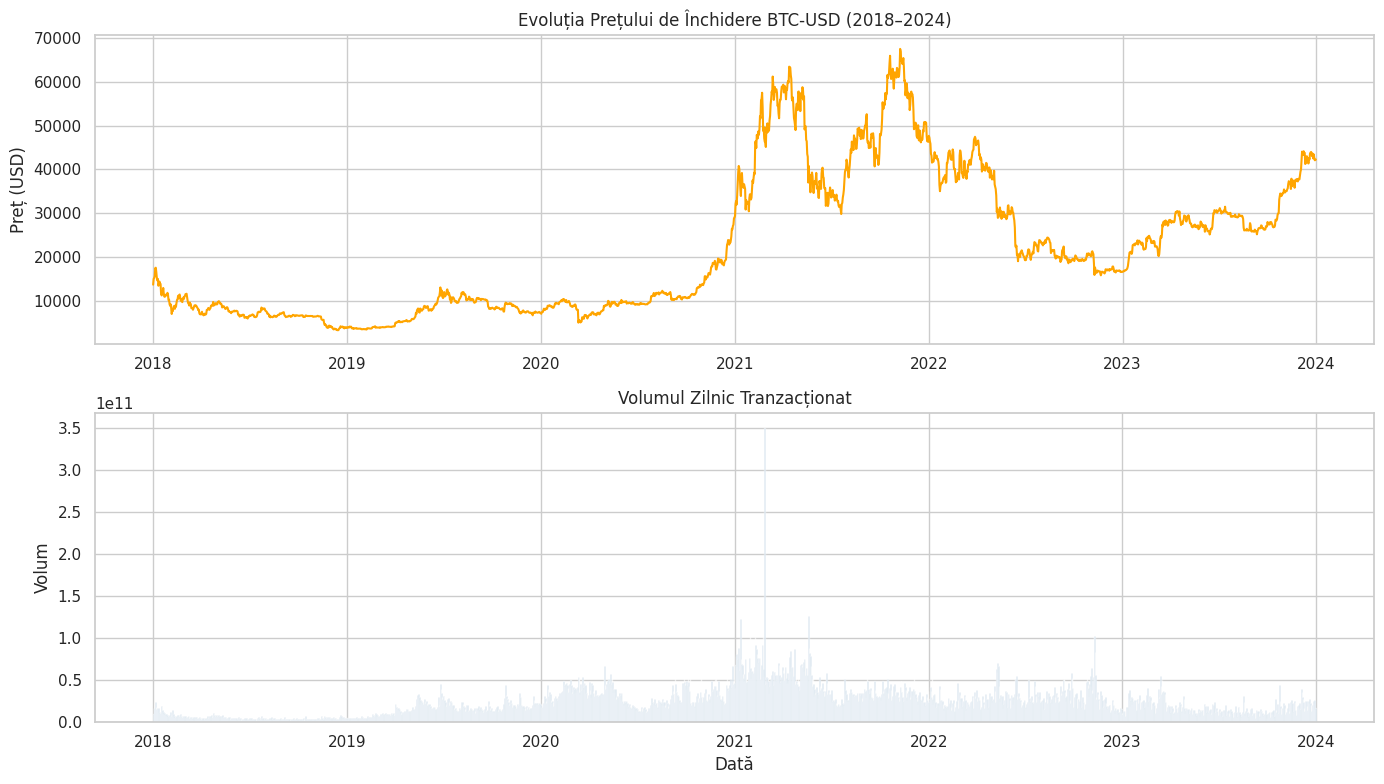

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Prețul de închidere
axes[0].plot(df_raw['Date'], df_raw['Close'], color='orange', linewidth=1.5)
axes[0].set_title('Evoluția Prețului de Închidere BTC-USD (2018–2024)')
axes[0].set_ylabel('Preț (USD)')
axes[0].set_xlabel('')

# Volumul tranzacționat
axes[1].bar(df_raw['Date'], df_raw['Volume'], color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Volumul Zilnic Tranzacționat')
axes[1].set_ylabel('Volum')
axes[1].set_xlabel('Dată')

plt.tight_layout()
plt.show()

### 2. Dataset features

| Feature | Formulă | Semnificație |
|---|---|---|
| `Daily_Return` | $(Close - Open) / Open \times 100$ | Variația procentuală zilnică |
| `Range` | $High - Low$ | Volatilitatea intra-day |
| `Lag_1` | $Close_{t-1}$ | Prețul de ieri |
| `Lag_7` | $Close_{t-7}$ | Prețul de acum 7 zile |
| `Rolling_Mean_7` | Media mobilă pe 7 zile | Trendul pe termen scurt |
| `Rolling_Std_7` | Deviația standard pe 7 zile | Volatilitatea recentă |
| **`Close_Tomorrow`** | $Close_{t+1}$ | **Variabila țintă** |

Nu există variabile categoriale în acest dataset, deci etapa de
encodare nu este necesară. Toate coloanele sunt numerice.

In [ ]:
df = df_raw.copy()

# Indicatori tehnici
df['Daily_Return']   = (df['Close'] - df['Open']) / df['Open'] * 100
df['Range']          = df['High'] - df['Low']
df['Lag_1']          = df['Close'].shift(1)
df['Lag_7']          = df['Close'].shift(7)
df['Rolling_Mean_7'] = df['Close'].rolling(window=7).mean()
df['Rolling_Std_7']  = df['Close'].rolling(window=7).std()

# Variabila țintă: prețul de Close din ziua URMĂTOARE
df['Close_Tomorrow'] = df['Close'].shift(-1)

# Eliminăm rândurile cu NaN apărute din shift/rolling
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dimensiune după feature engineering: {df.shape}")
display(df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume',
            'Daily_Return', 'Range', 'Lag_1', 'Lag_7',
            'Rolling_Mean_7', 'Rolling_Std_7', 'Close_Tomorrow']].head())

Dimensiune după feature engineering: (2183, 13)


Price,Date,Open,High,Low,Close,Volume,Daily_Return,Range,Lag_1,Lag_7,Rolling_Mean_7,Rolling_Std_7,Close_Tomorrow
0,2018-01-08,16476.199219,16537.900391,14208.200195,15170.099609,18413899776,-7.927190,2329.700195,16477.599609,13657.200195,16055.214146,1088.259908,14595.400391
1,2018-01-09,15123.700195,15497.500000,14424.000000,14595.400391,16659999744,-3.493191,1073.500000,15170.099609,14982.099609,15999.971401,1159.308475,14973.299805
2,2018-01-10,14588.500000,14973.299805,13691.200195,14973.299805,18500800512,2.637693,1282.099609,14595.400391,15201.000000,15967.442801,1188.294950,13405.799805
3,2018-01-11,14968.200195,15018.799805,13105.900391,13405.799805,16534099968,-10.438131,1912.899414,14973.299805,15599.200195,15654.099888,1539.014571,13980.599609
4,2018-01-12,13453.900391,14229.900391,13158.099609,13980.599609,12065699840,3.914844,1071.800781,13405.799805,17429.500000,15161.399833,1423.650197,14360.200195


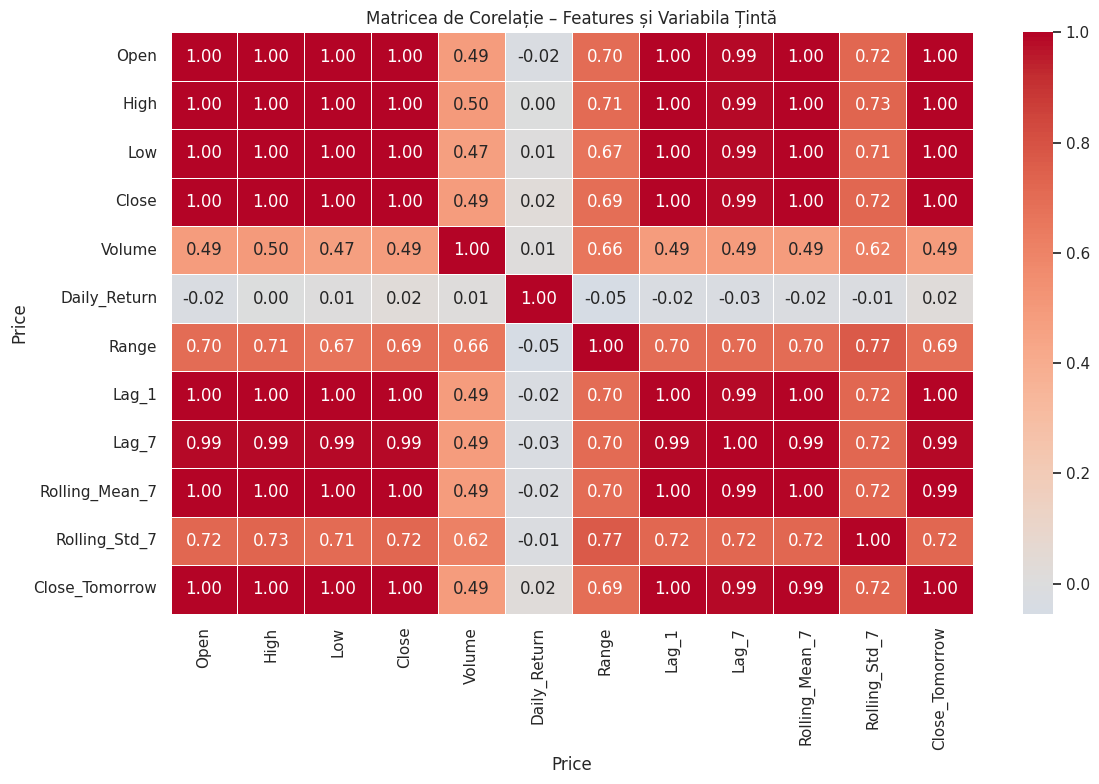

In [ ]:
cols_for_corr = ['Open', 'High', 'Low', 'Close', 'Volume',
                 'Daily_Return', 'Range', 'Lag_1', 'Lag_7',
                 'Rolling_Mean_7', 'Rolling_Std_7', 'Close_Tomorrow']

plt.figure(figsize=(12, 8))
sns.heatmap(df[cols_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matricea de Corelație – Features și Variabila Țintă')
plt.tight_layout()
plt.show()

### 3. Preprocesare: Împărțire și Scalare

Nu folosim împărțire aleatorie (`shuffle=True`)


Datele trebuie să rămână în ordine cronologică — altfel am „vedea viitorul"
în antrenament, ceea ce ar fi un data leakage.

Împărțim cronologic: 80% train (2018–2022), 20% test (2022–2024)

In [ ]:
# Definim features și target
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Daily_Return', 'Range', 'Lag_1', 'Lag_7',
                'Rolling_Mean_7', 'Rolling_Std_7']

X = df[feature_cols].values
y = df['Close_Tomorrow'].values

# Împărțire cronologică 80/20
split_idx = int(len(df) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scalare (fit DOAR pe train)
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} zile  |  Test: {X_test_sc.shape[0]} zile")
print(f"Perioada test: {df['Date'].iloc[split_idx].date()} → {df['Date'].iloc[-1].date()}")

Train: 1746 zile  |  Test: 437 zile
Perioada test: 2022-10-20 → 2023-12-30


### 4. Regresia Liniară Simplă

Folosim pretul de ieri (`Lag_1`)
pentru a prezice prețul de mâine (prețul de ieri este cel mai bun predictor simplu)

$$\hat{y}_{t+1} = \beta_0 + \beta_1 \cdot Close_t$$

=== Regresie Liniară Simplă (Lag_1 → Close_Tomorrow) ===
  R²   : 0.9829
  RMSE : $893.44
  MAE  : $583.10


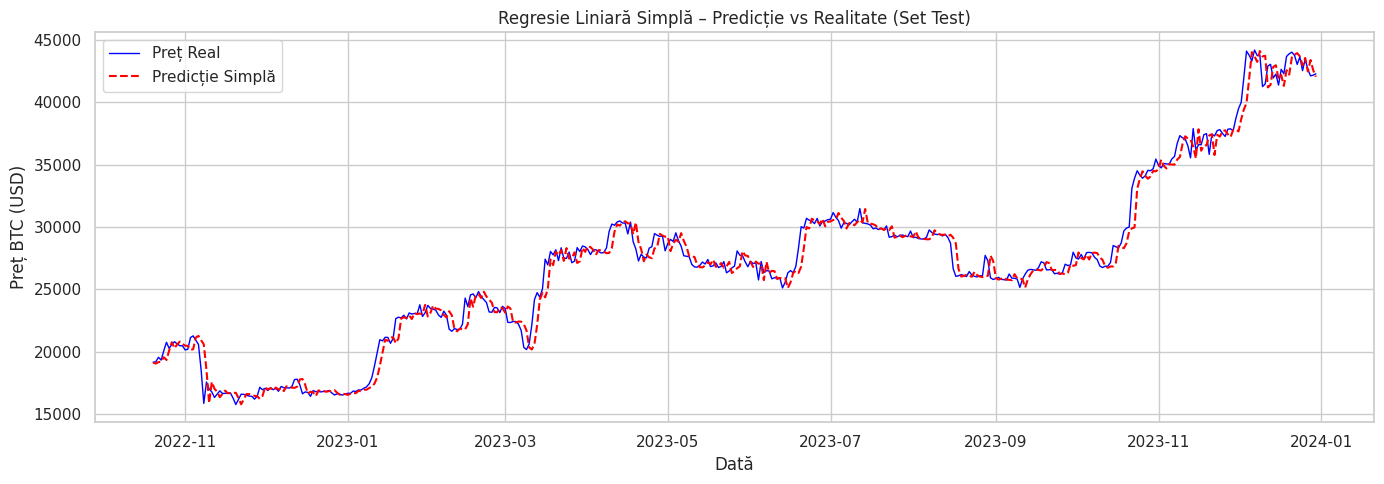

In [ ]:
# Indexul feature-ului Lag_1 în lista noastră
lag1_idx = feature_cols.index('Lag_1')

X_train_s = X_train_sc[:, [lag1_idx]]
X_test_s  = X_test_sc[:,  [lag1_idx]]

model_simplu = LinearRegression()
model_simplu.fit(X_train_s, y_train)
y_pred_s = model_simplu.predict(X_test_s)

rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))
mae_s  = mean_absolute_error(y_test, y_pred_s)
r2_s   = r2_score(y_test, y_pred_s)

print("=== Regresie Liniară Simplă (Lag_1 → Close_Tomorrow) ===")
print(f"  R²   : {r2_s:.4f}")
print(f"  RMSE : ${rmse_s:,.2f}")
print(f"  MAE  : ${mae_s:,.2f}")

# Grafic: Valori reale vs prezise
dates_test = df['Date'].iloc[split_idx:].values

plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test,   color='blue',  linewidth=1,   label='Preț Real')
plt.plot(dates_test, y_pred_s, color='red',   linewidth=1.5, linestyle='--', label='Predicție Simplă')
plt.title('Regresie Liniară Simplă – Predicție vs Realitate (Set Test)')
plt.xlabel('Dată')
plt.ylabel('Preț BTC (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 5. Regresia Liniară Multiplă

Oferim modelului toți indicatorii tehnici calculați.
Acum ecuația devine un hiperplan în spațiu multidimensional:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_{11} x_{11}$$

Fiecare coeficient $\beta_i$ reflectă importanța acelui indicator în predicție.

=== Regresie Liniară Multiplă (toate features) ===
  R²   : 0.9911
  RMSE : $643.90
  MAE  : $421.68


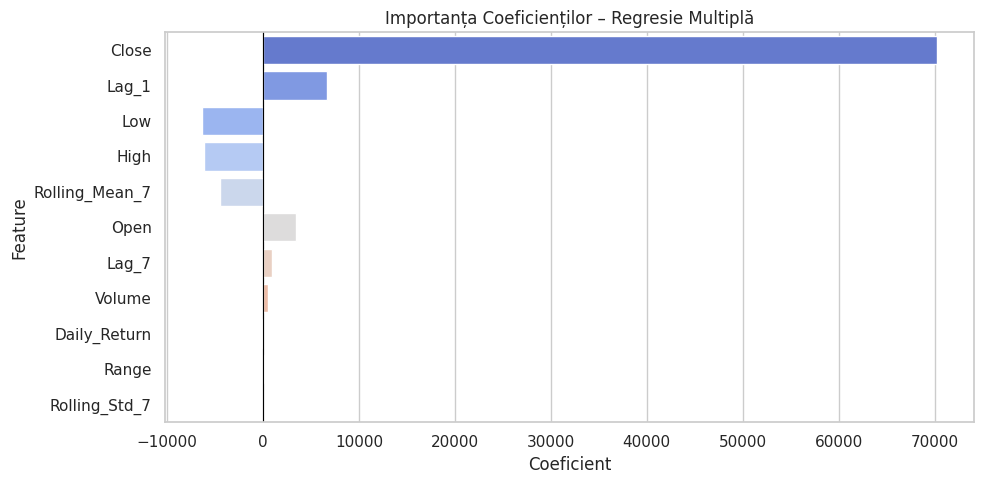

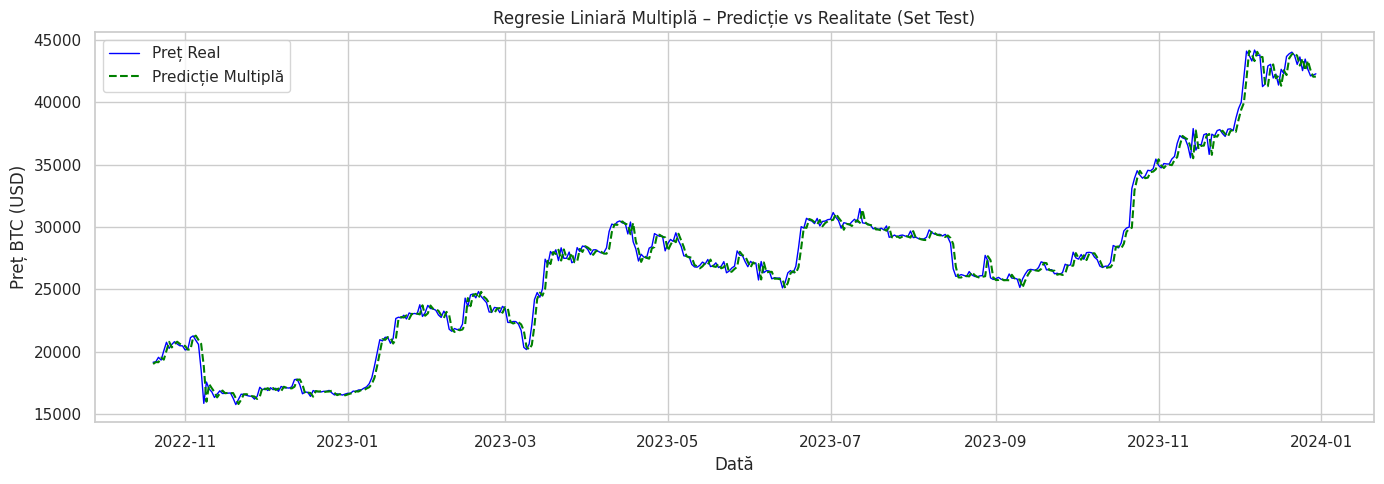

In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train_sc, y_train)
y_pred_m = model_multi.predict(X_test_sc)

rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_m))
mae_m  = mean_absolute_error(y_test, y_pred_m)
r2_m   = r2_score(y_test, y_pred_m)

print("=== Regresie Liniară Multiplă (toate features) ===")
print(f"  R²   : {r2_m:.4f}")
print(f"  RMSE : ${rmse_m:,.2f}")
print(f"  MAE  : ${mae_m:,.2f}")

# Importanța coeficienților
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficient': model_multi.coef_
}).sort_values('Coeficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coeficient', y='Feature',
            palette='coolwarm', hue='Feature', legend=False)
plt.title('Importanța Coeficienților – Regresie Multiplă')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Grafic: Valori reale vs prezise
plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test,   color='blue', linewidth=1,   label='Preț Real')
plt.plot(dates_test, y_pred_m, color='green', linewidth=1.5, linestyle='--', label='Predicție Multiplă')
plt.title('Regresie Liniară Multiplă – Predicție vs Realitate (Set Test)')
plt.xlabel('Dată')
plt.ylabel('Preț BTC (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 6. Regresia Polinomială

Regresia polinomială extinde
modelul liniar adăugând puteri ale variabilelor:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_d x^d$$

Testăm gradul 2 și gradul 3 și comparăm cu modelele liniare.

Un grad prea mare face modelul să memoreze
zgomotul din datele de antrenament și să generalizeze prost pe date noi (overfitting).

=== Regresie Polinomială (grad 2) ===
  R²   : 0.9904
  RMSE : $669.72
  MAE  : $436.27

=== Regresie Polinomială (grad 3) ===
  R²   : 0.9732
  RMSE : $1,117.76
  MAE  : $576.02



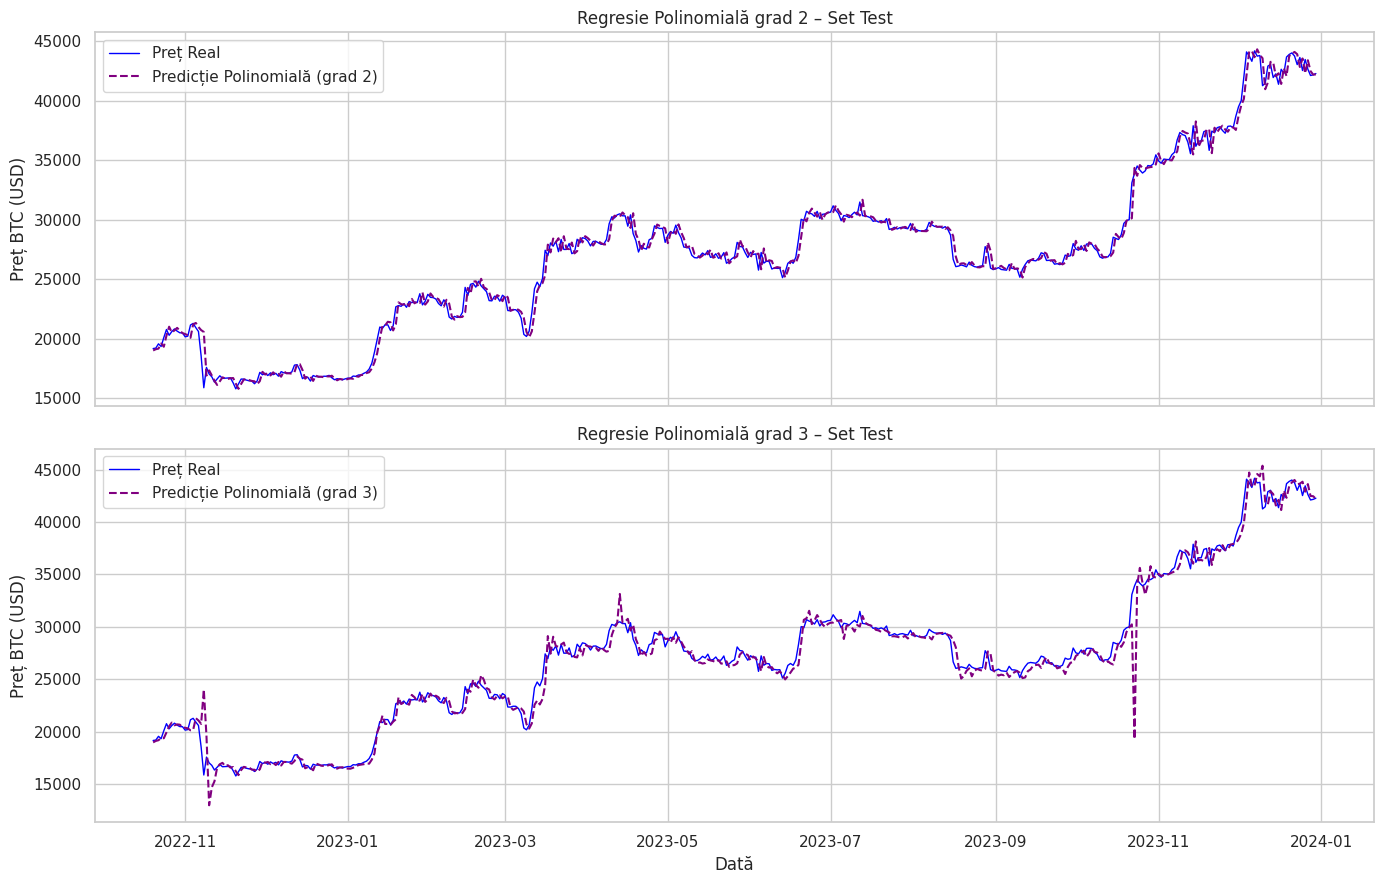

In [ ]:
results = {}  # Salvăm metricile pentru comparație finală

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_sc)
    X_test_poly  = poly.transform(X_test_sc)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)
    y_pred_poly = model_poly.predict(X_test_poly)

    rmse_p = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    mae_p  = mean_absolute_error(y_test, y_pred_poly)
    r2_p   = r2_score(y_test, y_pred_poly)

    results[f'Polinomial grad {degree}'] = {
        'y_pred': y_pred_poly, 'R2': r2_p, 'RMSE': rmse_p, 'MAE': mae_p
    }

    print(f"=== Regresie Polinomială (grad {degree}) ===")
    print(f"  R²   : {r2_p:.4f}")
    print(f"  RMSE : ${rmse_p:,.2f}")
    print(f"  MAE  : ${mae_p:,.2f}\n")

# Grafice pentru grad 2 și grad 3
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, degree in zip(axes, [2, 3]):
    y_pred_poly = results[f'Polinomial grad {degree}']['y_pred']
    ax.plot(dates_test, y_test,       color='blue',   linewidth=1,   label='Preț Real')
    ax.plot(dates_test, y_pred_poly,  color='purple', linewidth=1.5, linestyle='--',
            label=f'Predicție Polinomială (grad {degree})')
    ax.set_title(f'Regresie Polinomială grad {degree} – Set Test')
    ax.set_ylabel('Preț BTC (USD)')
    ax.legend()

axes[-1].set_xlabel('Dată')
plt.tight_layout()
plt.show()

### 7. Comparație finală și interpretarea rezultatelor

=== Tabel Comparativ – Toate Modelele ===


,R2,RMSE,MAE
Liniar Simplu,0.9829,$893,$583
Liniar Multiplu,0.9911,$644,$422
Polinomial grad 2,0.9904,$670,$436
Polinomial grad 3,0.9732,"$1,118",$576


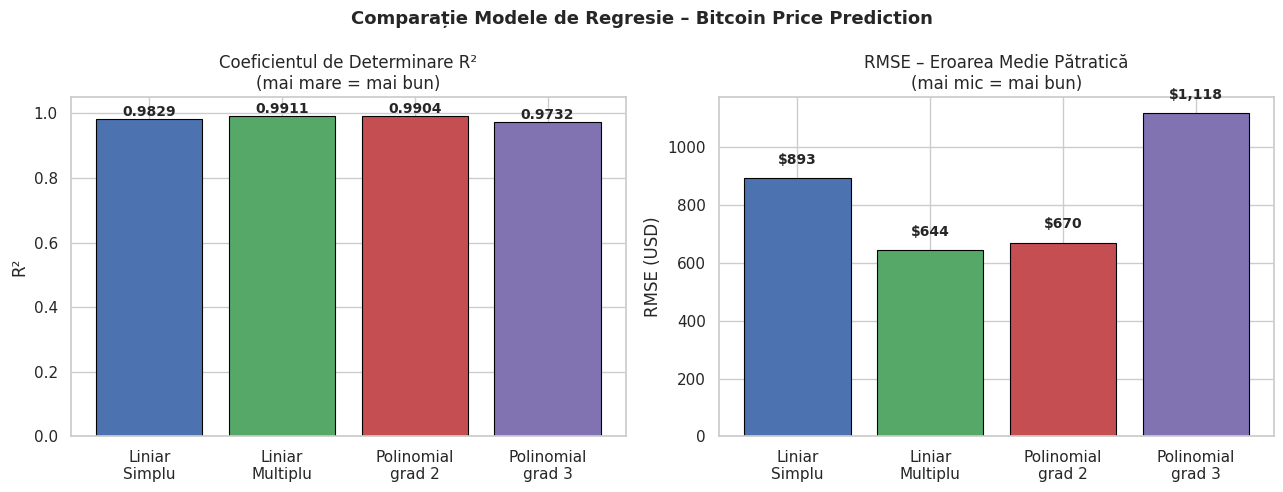

In [ ]:
# Compilăm toate rezultatele
all_results = {
    'Liniar Simplu':    {'R2': r2_s, 'RMSE': rmse_s, 'MAE': mae_s},
    'Liniar Multiplu':  {'R2': r2_m, 'RMSE': rmse_m, 'MAE': mae_m},
    'Polinomial grad 2': {'R2': results['Polinomial grad 2']['R2'],
                          'RMSE': results['Polinomial grad 2']['RMSE'],
                          'MAE':  results['Polinomial grad 2']['MAE']},
    'Polinomial grad 3': {'R2': results['Polinomial grad 3']['R2'],
                          'RMSE': results['Polinomial grad 3']['RMSE'],
                          'MAE':  results['Polinomial grad 3']['MAE']},
}

df_results = pd.DataFrame(all_results).T.round(4)
df_results['RMSE'] = df_results['RMSE'].apply(lambda x: f"${x:,.0f}")
df_results['MAE']  = df_results['MAE'].apply(lambda x: f"${x:,.0f}")
print("=== Tabel Comparativ – Toate Modelele ===")
display(df_results)

# Grafic R²
r2_vals    = [r2_s, r2_m,
              results['Polinomial grad 2']['R2'],
              results['Polinomial grad 3']['R2']]
rmse_vals  = [rmse_s, rmse_m,
              results['Polinomial grad 2']['RMSE'],
              results['Polinomial grad 3']['RMSE']]
labels     = ['Liniar\nSimplu', 'Liniar\nMultiplu', 'Polinomial\ngrad 2', 'Polinomial\ngrad 3']
colors     = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(labels, r2_vals, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Coeficientul de Determinare R²\n(mai mare = mai bun)', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(labels, rmse_vals, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('RMSE – Eroarea Medie Pătratică\n(mai mic = mai bun)', fontsize=12)
axes[1].set_ylabel('RMSE (USD)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparație Modele de Regresie – Bitcoin Price Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Concluzii

1. Regresia Liniară Simplă (bazată exclusiv pe `Lag_1`) confirmă că prețul
  de ieri este un predictor puternic al prețului de mâine.

2. Regresia Liniară Multiplă îmbunătățește performanța prin adăugarea
  indicatorilor tehnici (volum, volatilitate, medii mobile), oferind modelului
  o imagine mai completă a stării pieței.

3. Regresia Polinomială capturează relațiile neliniare din piață. Gradul 2
  aduce o îmbunătățire notabilă față de modelul liniar, însă gradul 3 poate
  introduce *overfitting*.

4. Prețul Bitcoin este influențat și de factori externi neincluși în model
(știri, reglementări, social media), care nu pot fi capturați
prin indicatori tehnici clasici. Acesta este motivul pentru care niciun model
de regresie simplă nu poate prezice perfect Bitcoin-ul.

## Partea 2: Clasificare Binară – Prezicerea Longevității Carierei NBA

**Dataset:** NBA Binary Classification Dataset  
**Sursa:** https://github.com/readytensor/rt-datasets-binary-classification  
**Obiectiv:** Prezicerea dacă un jucător NBA va activa **mai mult de 5 ani** în ligă,
pe baza statisticilor din primul sezon.

**Variabila țintă:** `TARGET_5Yrs`  
→ `1` = jucătorul a rămas în NBA **mai mult de 5 ani**  
→ `0` = jucătorul a părăsit NBA în **5 ani sau mai puțin**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")

### 1. Citirea și explorarea datelor

Descărcăm setul complet de date direct din repository-ul GitHub.  
Setul conține statistici individuale ale jucătorilor NBA din primul lor sezon în ligă.

In [ ]:
url = "https://raw.githubusercontent.com/readytensor/rt-datasets-binary-classification/main/datasets/processed/nba/nba.csv"
df = pd.read_csv(url)

print(f"Dimensiune dataset: {df.shape[0]} jucători × {df.shape[1]} coloane")
display(df.head())

Dimensiune dataset: 1294 jucători × 21 coloane


,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [ ]:
print("=== Informații generale ===")
df.info()

print("\n=== Statistici descriptive ===")
display(df.describe().round(2))

print("\n=== Valori lipsă per coloană ===")
print(df.isnull().sum())

=== Informații generale ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         1294 non-null   object 
 1   GP           1294 non-null   int64  
 2   MIN          1294 non-null   float64
 3   PTS          1294 non-null   float64
 4   FGM          1294 non-null   float64
 5   FGA          1294 non-null   float64
 6   FG%          1294 non-null   float64
 7   3P Made      1294 non-null   float64
 8   3PA          1294 non-null   float64
 9   3P%          1284 non-null   float64
 10  FTM          1294 non-null   float64
 11  FTA          1294 non-null   float64
 12  FT%          1294 non-null   float64
 13  OREB         1294 non-null   float64
 14  DREB         1294 non-null   float64
 15  REB          1294 non-null   float64
 16  AST          1294 non-null   float64
 17  STL          1294 non-null   float64
 18  BLK          1294 no

,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
count,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1284.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00,1294.00
mean,60.40,17.64,6.80,2.63,5.89,44.19,0.25,0.78,19.39,1.30,1.82,70.43,1.01,2.03,3.03,1.55,0.62,0.37,1.19,0.62
std,17.42,8.30,4.33,1.67,3.58,6.11,0.39,1.07,16.09,0.98,1.31,10.52,0.77,1.36,2.05,1.47,0.41,0.43,0.72,0.48
min,11.00,3.10,0.70,0.30,0.80,23.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.20,0.30,0.00,0.00,0.00,0.10,0.00
25%,47.00,10.90,3.70,1.40,3.30,40.22,0.00,0.00,0.00,0.60,0.90,64.90,0.40,1.00,1.50,0.60,0.30,0.10,0.70,0.00
50%,63.00,16.10,5.60,2.10,4.80,44.10,0.10,0.30,22.50,1.00,1.50,71.30,0.80,1.70,2.50,1.10,0.50,0.20,1.00,1.00
75%,77.00,22.90,8.80,3.40,7.50,47.80,0.40,1.20,32.70,1.60,2.30,77.60,1.40,2.60,3.90,2.00,0.80,0.50,1.50,1.00
max,82.00,40.90,28.20,10.20,19.80,73.70,2.30,6.50,100.00,7.70,10.20,100.00,5.30,9.60,13.90,10.60,2.50,3.90,4.40,1.00



=== Valori lipsă per coloană ===
Name            0
GP              0
MIN             0
PTS             0
FGM             0
FGA             0
FG%             0
3P Made         0
3PA             0
3P%            10
FTM             0
FTA             0
FT%             0
OREB            0
DREB            0
REB             0
AST             0
STL             0
BLK             0
TOV             0
TARGET_5Yrs     0
dtype: int64


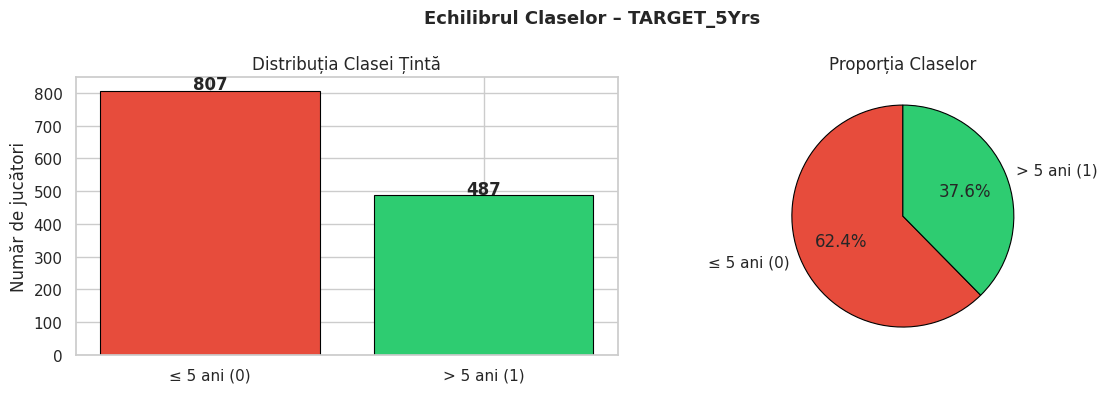

Clasa 0 (≤5 ani): 487 jucători (37.6%)
Clasa 1 (>5 ani): 807 jucători (62.4%)


In [ ]:
# Identificăm coloana țintă
target_col = 'TARGET_5Yrs'
id_col     = 'Name'

counts = df[target_col].value_counts()
labels = ['≤ 5 ani (0)', '> 5 ani (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuția Clasei Țintă')
axes[0].set_ylabel('Număr de jucători')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Proporția Claselor')

plt.suptitle('Echilibrul Claselor – TARGET_5Yrs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Clasa 0 (≤5 ani): {counts[0]} jucători ({counts[0]/len(df)*100:.1f}%)")
print(f"Clasa 1 (>5 ani): {counts[1]} jucători ({counts[1]/len(df)*100:.1f}%)")

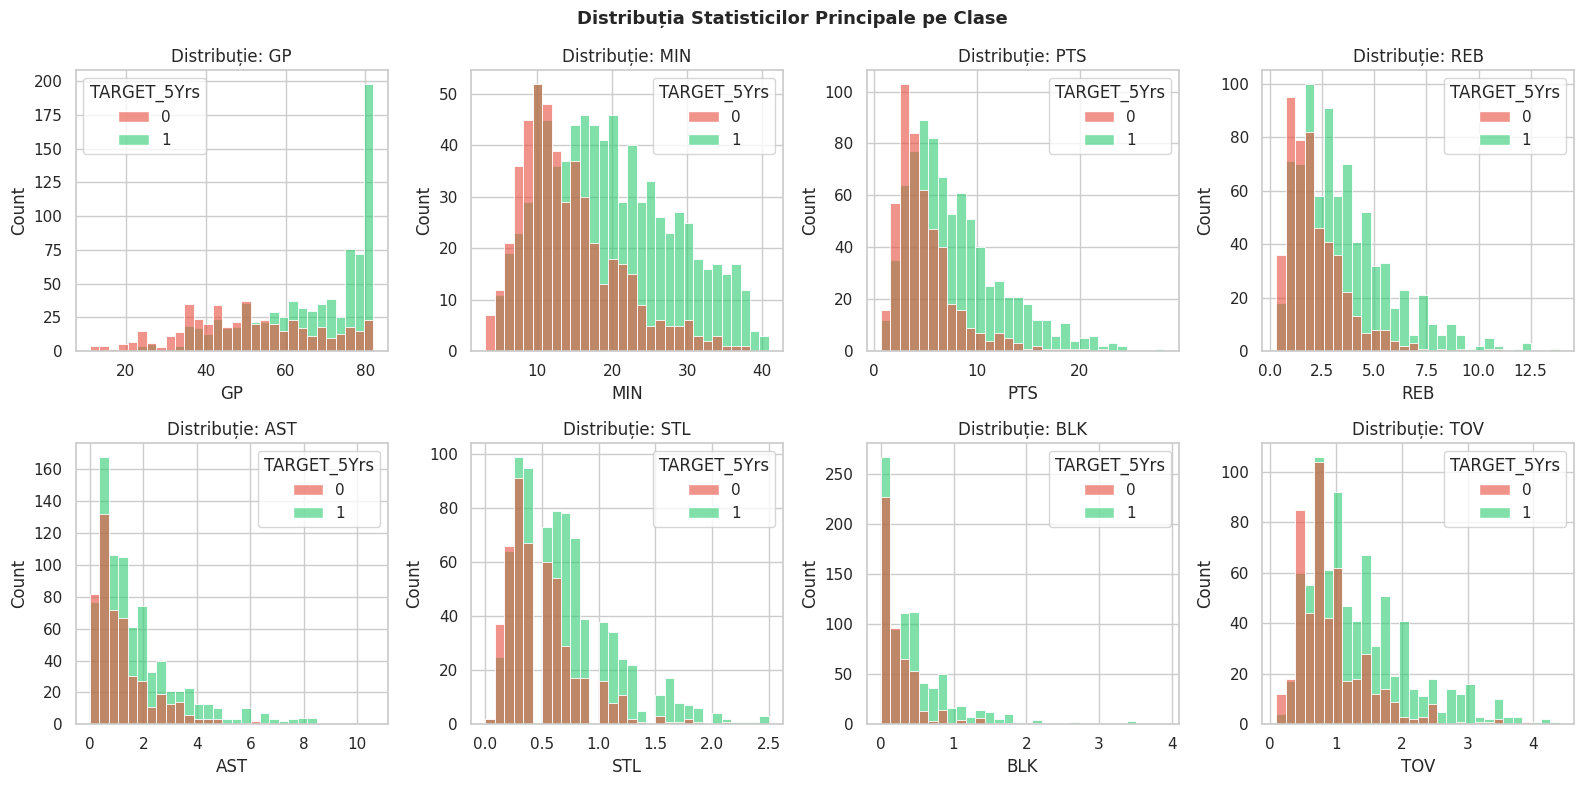

In [ ]:
features_viz = ['GP', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features_viz):
    sns.histplot(data=df, x=feat, hue=target_col, bins=30,
                 palette={0: '#e74c3c', 1: '#2ecc71'},
                 alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Distribuție: {feat}')
    axes[i].set_xlabel(feat)

plt.suptitle('Distribuția Statisticilor Principale pe Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

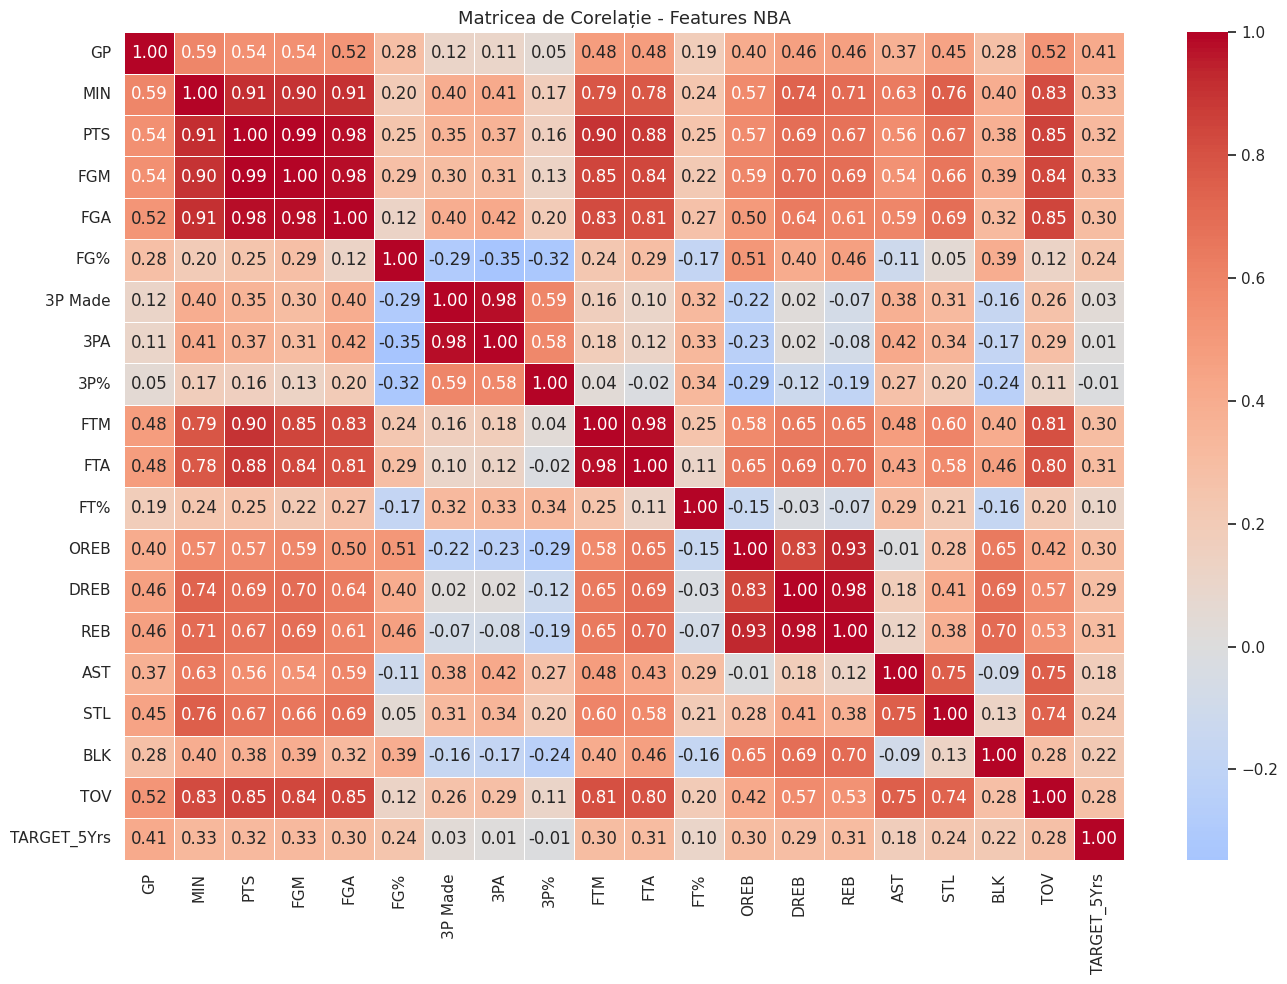

In [ ]:
feature_cols = [c for c in df.columns if c not in [id_col, target_col]]

# Selectează doar coloanele numerice
numeric_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols + [target_col]].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Matricea de Corelație - Features NBA', fontsize=13)
plt.tight_layout()
plt.show()

### 2. Preprocesarea Datelor

Înainte de antrenarea modelului aplicăm mai multe etape de preprocesare pentru a pregăti datele în mod corect.



#### 2.1 Eliminarea coloanelor nerelevante

Eliminăm coloana `Name`, deoarece reprezintă doar identificatorul jucătorului și nu contribuie la procesul de predicție.



#### 2.2 Analiza valorilor lipsă

Datasetul conține 10 valori lipsă distribuite în câteva coloane numerice.
Pentru tratarea acestora alegem imputarea cu mediană.



#### 2.3 Separarea variabilelor

Separăm:
- variabilele explicative (`X`)
- variabila țintă (`y`)



#### 2.4 Împărțirea Train/Test

Împărțim datele:
- 80% pentru antrenare
- 20% pentru testare

Folosim `stratify=y` pentru a păstra proporția claselor în ambele subseturi.



#### 2.5 Imputarea valorilor lipsă

Aplicăm `SimpleImputer(strategy="median")`.

Imputerul este:
- antrenat doar pe datele de Train (`fit`)
- aplicat atât pe Train cât și pe Test (`transform`)

pentru a evita *data leakage*.



#### 2.6 Standardizarea datelor

Aplicăm `StandardScaler` pentru a aduce toate variabilele la aceeași scară:


$$z = \frac{x - \mu}{\sigma}$$

unde:
- $\mu$ = media
- $\sigma$ = deviația standard

In [ ]:
# 2.1 Eliminarea coloanelor nerelevante
df_clean = df.drop(columns=[id_col])

# 2.2 Analiza valorilor lips
print(f"Valori lipsă totale: {df_clean.isnull().sum().sum()}")

# 2.3 Separarea variabilelor
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Features: {X.shape[1]} coloane numerice")
print(f"Clase: {sorted(y.unique())}")
print(f"Distribuție clase: {dict(y.value_counts())}")

# 2.4 Împărțirea Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]} jucători")
print(f"Test:  {X_test.shape[0]} jucători")

print(f"Proporție clasa 1 în Train: {y_train.mean()*100:.1f}%")
print(f"Proporție clasa 1 în Test:  {y_test.mean()*100:.1f}%")

# 2.5 Imputarea valorilor lipsă
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print(f"\nNaN după imputare: {np.isnan(X_train).sum()}")

# 2.6 Standardizarea datelor
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("\n✅ Preprocesare completă!")

Valori lipsă totale: 10
Features: 19 coloane numerice
Clase: [np.int64(0), np.int64(1)]
Distribuție clase: {1: np.int64(807), 0: np.int64(487)}

Train: 1035 jucători
Test:  259 jucători
Proporție clasa 1 în Train: 62.3%
Proporție clasa 1 în Test:  62.5%

NaN după imputare: 0

✅ Preprocesare completă!


### 3. Regresia Logistică

#### 3.1 Funcția Sigmoid

Functia sigmoid acționează ca un convertor care transformă orice valoare reală într-o probabilitate între 0 și 1, oferindu-ne un rezultat predictiv mult mai intuitiv:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

unde $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$

**Regula de decizie:**
- Dacă $\sigma(z) \geq 0.5$ → modelul prezice **Clasa 1** (>5 ani în NBA)
- Dacă $\sigma(z) < 0.5$ → modelul prezice **Clasa 0** (≤5 ani în NBA)

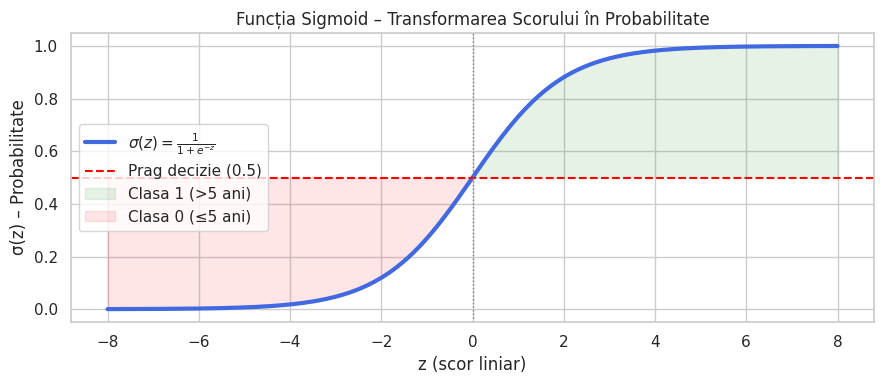

In [ ]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(9, 4))
plt.plot(z, sigmoid, color='royalblue', linewidth=3, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Prag decizie (0.5)')
plt.axvline(0,   color='gray', linestyle=':', linewidth=1)
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid >= 0.5), alpha=0.1, color='green', label='Clasa 1 (>5 ani)')
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid <  0.5), alpha=0.1, color='red',   label='Clasa 0 (≤5 ani)')
plt.title('Funcția Sigmoid – Transformarea Scorului în Probabilitate')
plt.xlabel('z (scor liniar)')
plt.ylabel('σ(z) – Probabilitate')
plt.legend(loc='center left')
plt.tight_layout()
plt.show()

#### 3.2 Antrenarea Modelului

Antrenăm modelul pe datele scalate și evaluăm performanța pe setul de test.

In [ ]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_sc, y_train)

y_pred       = model_lr.predict(X_test_sc)
y_pred_proba = model_lr.predict_proba(X_test_sc)[:, 1]  # probabilități clasa 1

print("✅ Model antrenat cu succes!")
print(f"   Parametri: {model_lr.get_params()}")

✅ Model antrenat cu succes!
   Parametri: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


### 4. Evaluarea Modelului

Folosim 4 metrici pentru a evalua performanța sistemului:

| Metrică &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | Formulă &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | Interpretare |
| :--- | :---: | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Procentul total de predicții corecte din întregul set de date. |
| **Precision** | $\frac{TP}{TP + FP}$ | Din toate instanțele prezise ca fiind pozitive, câte sunt corecte? |
| **Recall** | $\frac{TP}{TP + FN}$ | Din toate instanțele care sunt cu adevărat pozitive, câte au fost identificate? |
| **F1-Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Media armonică a Precision și Recall, utilă pentru un set de date neechilibrat. |

In [ ]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("      PERFORMANȚA REGRESIEI LOGISTICE")
print("=" * 45)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 45)
print("\nRaport detaliat:")
print(classification_report(y_test, y_pred,
                            target_names=['≤ 5 ani (0)', '> 5 ani (1)']))

      PERFORMANȚA REGRESIEI LOGISTICE
  Accuracy  : 74.13%
  Precision : 75.13%
  Recall    : 87.65%
  F1-Score  : 80.91%
  AUC-ROC   : 0.8165

Raport detaliat:
              precision    recall  f1-score   support

 ≤ 5 ani (0)       0.71      0.52      0.60        97
 > 5 ani (1)       0.75      0.88      0.81       162

    accuracy                           0.74       259
   macro avg       0.73      0.70      0.70       259
weighted avg       0.74      0.74      0.73       259



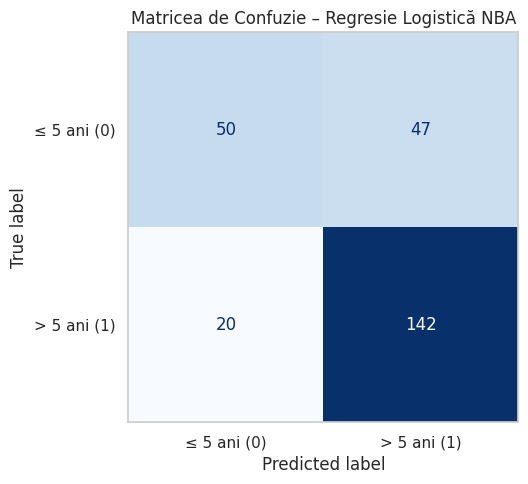

True Positives  (TP): 142  — prezis corect: carieră lungă
True Negatives  (TN): 50  — prezis corect: carieră scurtă
False Positives (FP): 47  — alarmă falsă: prezis lungă, era scurtă
False Negatives (FN): 20  — ratare: prezis scurtă, era lungă


In [ ]:
matrice = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matrice,
                              display_labels=['≤ 5 ani (0)', '> 5 ani (1)'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Matricea de Confuzie – Regresie Logistică NBA', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

TP = matrice[1,1]; TN = matrice[0,0]
FP = matrice[0,1]; FN = matrice[1,0]
print(f"True Positives  (TP): {TP}  — prezis corect: carieră lungă")
print(f"True Negatives  (TN): {TN}  — prezis corect: carieră scurtă")
print(f"False Positives (FP): {FP}  — alarmă falsă: prezis lungă, era scurtă")
print(f"False Negatives (FN): {FN}  — ratare: prezis scurtă, era lungă")

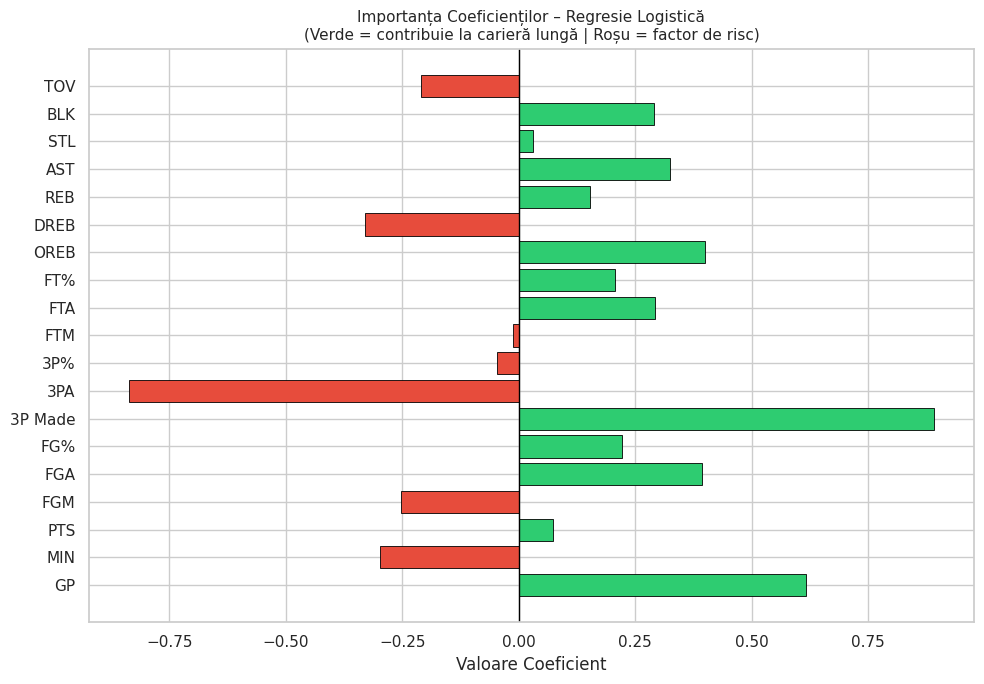

In [ ]:
feature_names = df_clean.drop(columns=[target_col]).columns.tolist()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficient': model_lr.coef_[0]
})

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficient']]
plt.barh(coef_df['Feature'], coef_df['Coeficient'],
         color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linewidth=1)
plt.title('Importanța Coeficienților – Regresie Logistică\n'
          '(Verde = contribuie la carieră lungă | Roșu = factor de risc)', fontsize=11)
plt.xlabel('Valoare Coeficient')
plt.tight_layout()
plt.show()

### 5. Concluzii

1. Accuracy ridicat indică faptul că modelul identifică corect
  marea majoritate a jucătorilor, atât cei cu carieră lungă, cât și cei cu carieră scurtă.

2. Matricea de confuzie relevă tipul de erori predominant:
  *False Negatives* (jucători buni clasificați greșit ca „carieră scurtă")
  sunt mai costisitori din perspectivă practică.

3. Coeficienții indică că statisticile ofensive (`3P Made`-aruncari de 3 puncte, `OREB`-rebounduri ofensive, `FGA`-totalul aruncarilor) sunt cei
  mai importanți predictori pentru longevitatea în NBA.

4. Modelul se bazează exclusiv pe statistici din primul sezon.
Factori precum personalitatea, sănătatea sau contextul echipei nu sunt capturați.

## Partea 3: Clasificare Multiclasă, Reducere Dimensională, Clustering – Recunoașterea cifrelor scrise de mână



**Dataset:** Digit Recognizer – Kaggle  
**Sursa:** https://www.kaggle.com/competitions/digit-recognizer/data (`train.csv`)    
**Obiectiv:** Clasificarea automată a cifrelor scrise de mână (0–9) din imagini de **28×28 pixeli** (784 trăsături).

**Modele de clasificare:**
- K-Nearest Neighbors (KNN)
- Nearest Centroid
- Arbore Decizional

**Reducere dimensională:**
- MDS (Multidimensional Scaling)

**Clustering:**
- K-Means
- K-Medoids
- Clustering Ierarhic (Agglomerative)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             adjusted_rand_score, silhouette_score)

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")

### 1. Citirea și Explorarea Datelor

Setul de date conține **42.000 de imagini** de cifre scrise de mână, fiecare reprezentată
ca un vector de **784 de valori de pixeli**.
Fiecare pixel are o valoare între 0 (alb) și 255 (negru).

**Variabila țintă:** `label` — cifra corespunzătoare imaginii (0–9)  
**Features:** `pixel0` ... `pixel783` — intensitatea fiecărui pixel

In [ ]:
df = pd.read_csv('train.csv')

print(f"Dimensiune dataset: {df.shape[0]} imagini × {df.shape[1]} coloane")
print(f"Clase unice: {sorted(df['label'].unique())}")

Dimensiune dataset: 16061 imagini × 785 coloane
Clase unice: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [ ]:
print("=== Informații generale ===")
df.info()

print("\n=== Valori lipsă ===")
print(df.isnull().sum().sum(), "valori lipsă în total")

print("\n=== Distribuția claselor ===")
print(df['label'].value_counts().sort_index())

=== Informații generale ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB

=== Valori lipsă ===
0 valori lipsă în total

=== Distribuția claselor ===
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


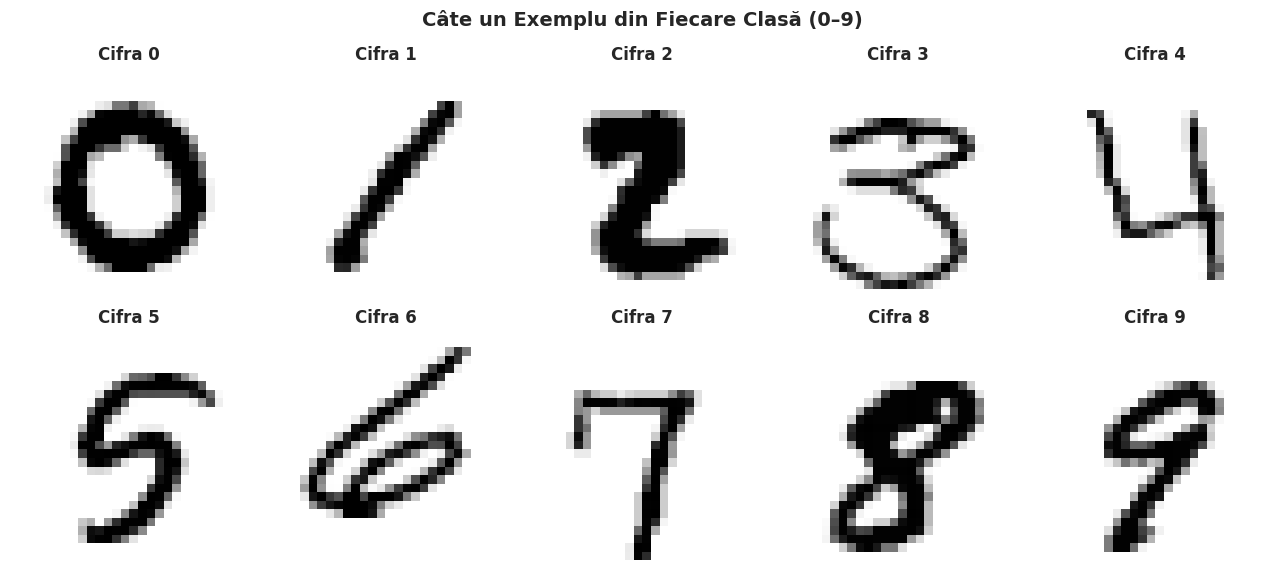

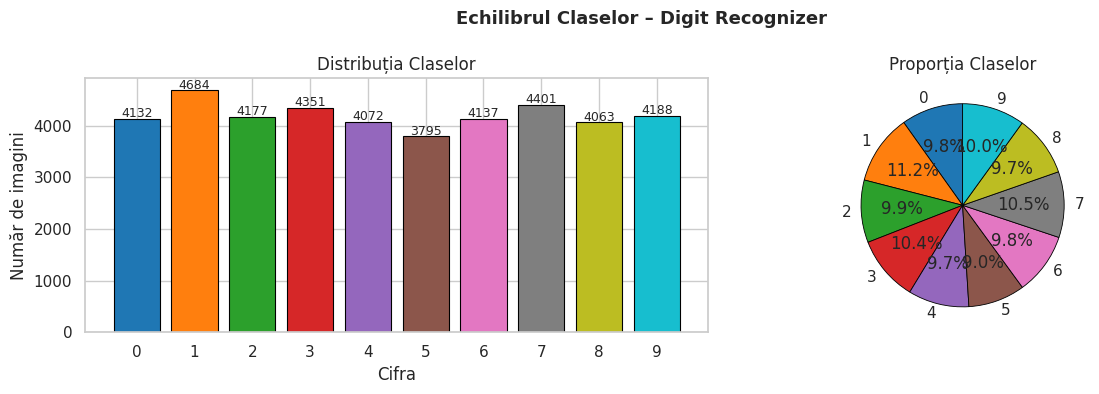

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for digit in range(10):
    sample_pixels = df[df['label'] == digit].iloc[0, 1:].values.reshape(28, 28)
    axes[digit].imshow(sample_pixels, cmap='gray_r')
    axes[digit].set_title(f'Cifra {digit}', fontsize=12, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Câte un Exemplu din Fiecare Clasă (0–9)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribuția claselor
counts = df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index, counts.values, color=sns.color_palette("tab10", 10),
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuția Claselor')
axes[0].set_xlabel('Cifra')
axes[0].set_ylabel('Număr de imagini')
axes[0].set_xticks(range(10))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

axes[1].pie(counts.values, labels=[str(i) for i in range(10)],
            autopct='%1.1f%%', colors=sns.color_palette("tab10", 10),
            startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.6})
axes[1].set_title('Proporția Claselor')

plt.suptitle('Echilibrul Claselor – Digit Recognizer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Preprocesarea Datelor

#### 2.1 Separarea variabilelor și Curățarea datelor

Separăm pixelii (features) de eticheta cifrei (target). Nu există valori lipsă
și nu există variabile categoriale de encodat.

#### 2.2 Împărțirea Train/Test

Împărțim **80% antrenament / 20% testare**.

#### 2.3 Scalarea datelor

Normalizăm valorile pixelilor din intervalul $[0, 255]$ în $[0, 1]$:

$$x_{norm} = \frac{x}{255}$$

Aceasta este echivalentă cu o scalare min-max și este practica standard
pentru datele de tip imagine.

#### 2.4 Reducere dimensională prin PCA (preprocesor)

784 de features reprezintă o dimensionalitate foarte ridicată, care:
- încetinește semnificativ algoritmii bazați pe distanță (KNN, MDS, clustering)
- introduce **blestemul dimensionalității** (*curse of dimensionality*)

Aplicăm **PCA** ca etapă de preprocesare, păstrând componentele care explică
**cel puțin 95% din varianță**. Aceasta reduce dimensionalitatea de la 784
la un număr mult mai mic de componente, fără pierdere semnificativă de informație.

Features (X): (42000, 784)  |  Target (y): (42000,)
Valori lipsă: 0

Train: 33600 imagini  |  Test: 8400 imagini
Interval valori pixeli după normalizare: [0.0, 1.0]

Dimensionalitate după PCA: 153 componente (din 784)
Varianță cumulată explicată: 95.01%


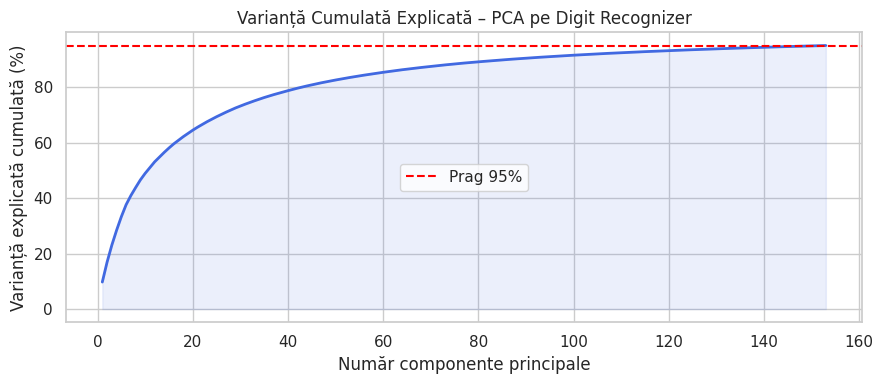

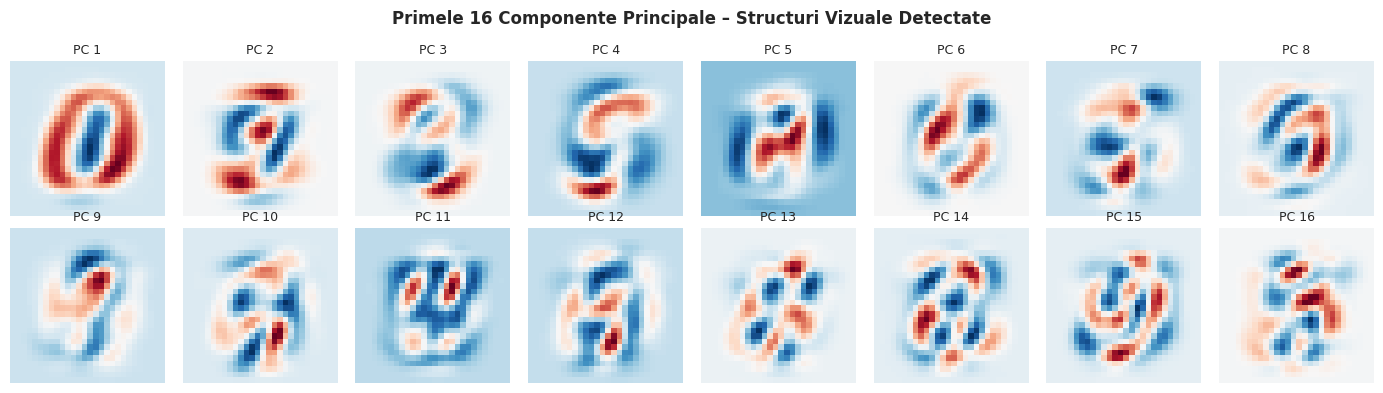

In [ ]:
# 2.1 Separarea variabilelor
X = df.drop(columns=['label']).values
y = df['label'].values

print(f"Features (X): {X.shape}  |  Target (y): {y.shape}")
print(f"Valori lipsă: {np.isnan(X).sum()}")

# 2.2 Împărțirea Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} imagini  |  Test: {X_test.shape[0]} imagini")

# 2.3 Scalarea [0, 255] → [0, 1]
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0
print(f"Interval valori pixeli după normalizare: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")

# 2.4 Reducere PCA (95% varianță)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca  = pca.transform(X_test_norm)

print(f"\nDimensionalitate după PCA: {X_train_pca.shape[1]} componente (din 784)")
print(f"Varianță cumulată explicată: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ── Grafic 1: Curba varianței cumulate ──────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='royalblue', linewidth=2)
plt.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.1, color='royalblue')
plt.axhline(95, color='red', linestyle='--', linewidth=1.5, label='Prag 95%')
plt.xlabel('Număr componente principale')
plt.ylabel('Varianță explicată cumulată (%)')
plt.title('Varianță Cumulată Explicată – PCA pe Digit Recognizer')
plt.legend()
plt.tight_layout()
plt.show()

# ── Grafic 2: Eigendigits (primele 16 componente ca imagini) ─────────────────
fig2, axes2 = plt.subplots(2, 8, figsize=(14, 4))
axes2 = axes2.flatten()
for i in range(16):
    component_img = pca.components_[i].reshape(28, 28)
    axes2[i].imshow(component_img, cmap='RdBu_r')
    axes2[i].set_title(f'PC {i+1}', fontsize=9)
    axes2[i].axis('off')
plt.suptitle('Primele 16 Componente Principale – Structuri Vizuale Detectate',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Clasificare Multiclasă

#### 3.1 K-Nearest Neighbors (KNN)

**Principiu:** Când vine o imagine nouă, KNN calculează distanța față de toate
imaginile din antrenament și atribuie clasa votată de cei mai apropiați $K$ vecini.

$$d(x, x') = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2} \quad $$

**Alegerea lui $K$:** Un $K$ mic (ex. $K=1$) memorează zgomotul din date (*overfitting*),
iar un $K$ mare simplifică prea mult granița de decizie. Testăm mai multe valori
și alegem $K$-ul optim pe setul de validare.

K= 1  →  Train: 100.00%  |  Test: 96.85%
K= 3  →  Train: 98.41%  |  Test: 96.85%
K= 5  →  Train: 97.99%  |  Test: 96.86%
K= 7  →  Train: 97.64%  |  Test: 96.73%
K= 9  →  Train: 97.41%  |  Test: 96.61%
K=11  →  Train: 97.15%  |  Test: 96.40%
K=15  →  Train: 96.80%  |  Test: 96.10%
K=20  →  Train: 96.42%  |  Test: 95.58%


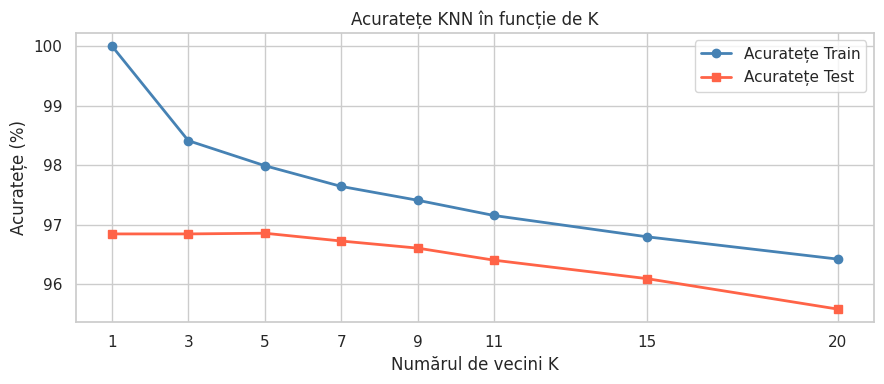


✅ Cel mai bun K = 5  (Acuratețe Test: 96.86%)


In [ ]:
# Alegerea optimă a lui K
k_values   = [1, 3, 5, 7, 9, 11, 15, 20]
acc_train  = []
acc_test   = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    acc_train.append(accuracy_score(y_train, knn.predict(X_train_pca)))
    acc_test.append(accuracy_score(y_test,  knn.predict(X_test_pca)))
    print(f"K={k:2d}  →  Train: {acc_train[-1]*100:.2f}%  |  Test: {acc_test[-1]*100:.2f}%")

# Grafic
plt.figure(figsize=(9, 4))
plt.plot(k_values, [a*100 for a in acc_train], 'o-', color='steelblue',
         linewidth=2, label='Acuratețe Train')
plt.plot(k_values, [a*100 for a in acc_test],  's-', color='tomato',
         linewidth=2, label='Acuratețe Test')
plt.xlabel('Numărul de vecini K')
plt.ylabel('Acuratețe (%)')
plt.title('Acuratețe KNN în funcție de K')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(acc_test)]
print(f"\n✅ Cel mai bun K = {best_k}  (Acuratețe Test: {max(acc_test)*100:.2f}%)")

=== KNN (K=5) – Acuratețe Test: 96.86% ===

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       827
           1       0.96      1.00      0.98       937
           2       0.99      0.96      0.98       835
           3       0.97      0.96      0.96       870
           4       0.98      0.96      0.97       814
           5       0.96      0.96      0.96       759
           6       0.98      0.99      0.98       827
           7       0.97      0.97      0.97       880
           8       0.99      0.92      0.95       813
           9       0.94      0.96      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



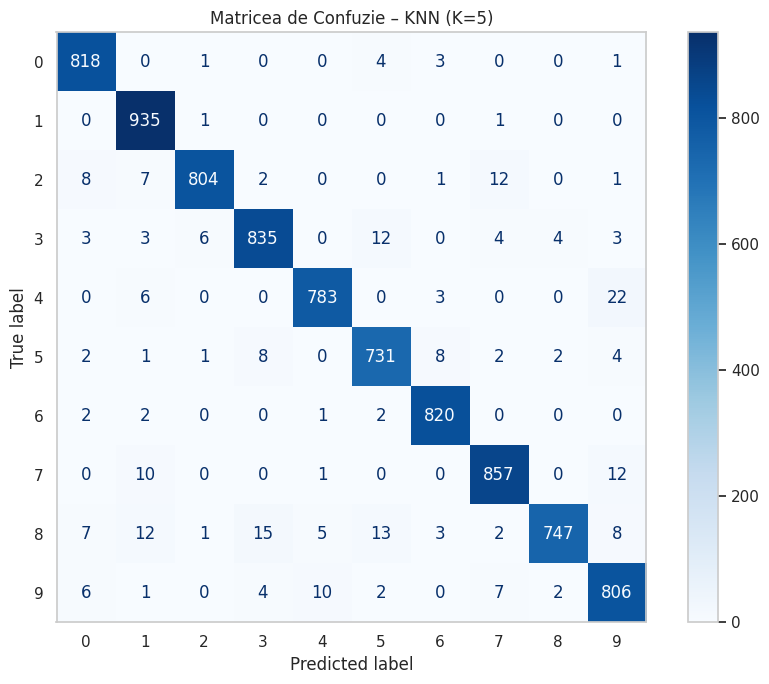

In [ ]:
# Model KNN final cu K optim
model_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
model_knn.fit(X_train_pca, y_train)
y_pred_knn = model_knn.predict(X_test_pca)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"=== KNN (K={best_k}) – Acuratețe Test: {acc_knn*100:.2f}% ===\n")
print(classification_report(y_test, y_pred_knn))

# Matrice de confuzie
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_knn),
    display_labels=list(range(10))
).plot(cmap='Blues', ax=ax, colorbar=True)
plt.title(f'Matricea de Confuzie – KNN (K={best_k})', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

#### 3.2 Nearest Centroid

**Principiu:** Algoritmul calculează **centrul de greutate** (centroidul) al fiecărei
clase în spațiul features:

$$\mu_k = \frac{1}{|C_k|} \sum_{x \in C_k} x$$

O imagine nouă este atribuită clasei al cărei centroid este **cel mai aproape**:

$$\hat{y} = \arg\min_k \, d(x, \mu_k)$$

=== Nearest Centroid – Acuratețe Test: 80.58% ===

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       827
           1       0.75      0.96      0.84       937
           2       0.86      0.76      0.81       835
           3       0.74      0.75      0.74       870
           4       0.79      0.80      0.79       814
           5       0.72      0.65      0.68       759
           6       0.87      0.87      0.87       827
           7       0.90      0.84      0.87       880
           8       0.80      0.73      0.76       813
           9       0.73      0.79      0.76       838

    accuracy                           0.81      8400
   macro avg       0.81      0.80      0.80      8400
weighted avg       0.81      0.81      0.81      8400



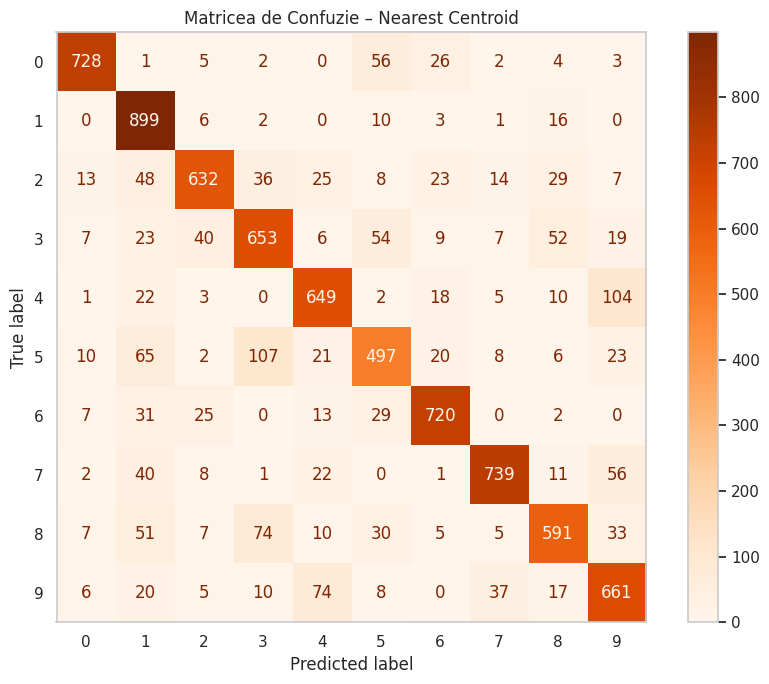

In [ ]:
model_nc = NearestCentroid()
model_nc.fit(X_train_pca, y_train)
y_pred_nc = model_nc.predict(X_test_pca)

acc_nc = accuracy_score(y_test, y_pred_nc)
print(f"=== Nearest Centroid – Acuratețe Test: {acc_nc*100:.2f}% ===\n")
print(classification_report(y_test, y_pred_nc))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nc),
    display_labels=list(range(10))
).plot(cmap='Oranges', ax=ax, colorbar=True)
plt.title('Matricea de Confuzie – Nearest Centroid', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

#### 3.3 Arbore decizional

Arborele construiește o serie de **reguli de decizie** de tip
*if-else* pe valorile pixelilor, ramificând recursiv datele în subgrupuri
tot mai omogene.

$$\text{Gini}(S) = 1 - \sum_{k=0}^{9} p_k^2$$

unde $p_k$ este proporția clasei $k$ în subgrupul $S$.

`max_depth` controlează adâncimea maximă a arborelui.
Cu `max_depth` limitat, modelul generalizează mai bine pe date noi

Fără max_depth  →  Train: 100.00%  |  Test: 82.07%
  Adâncime arbore: 48  |  Frunze: 2963


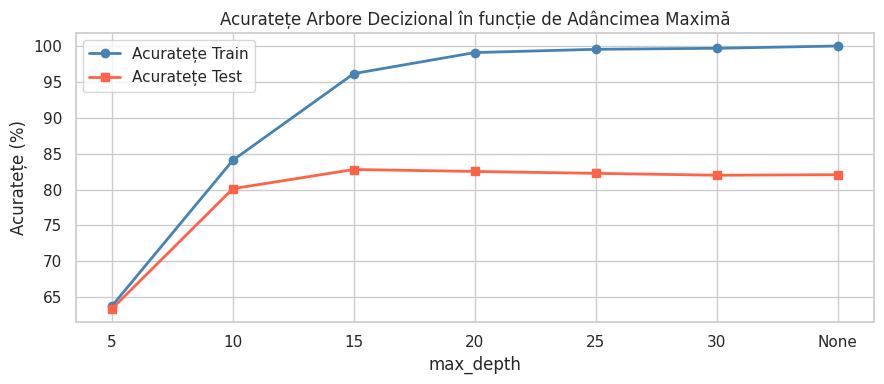


✅ Cel mai bun max_depth = 15


In [ ]:
# Arbore fără max_depth (overfitting vizibil)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_pca, y_train)

acc_train_full = dt_full.score(X_train_pca, y_train)
acc_test_full  = accuracy_score(y_test, dt_full.predict(X_test_pca))

print(f"Fără max_depth  →  Train: {acc_train_full*100:.2f}%  |  Test: {acc_test_full*100:.2f}%")
print(f"  Adâncime arbore: {dt_full.get_depth()}  |  Frunze: {dt_full.get_n_leaves()}")

# Găsim max_depth optim
depth_vals    = [5, 10, 15, 20, 25, 30, None]
depth_labels  = [str(d) if d else 'None' for d in depth_vals]
acc_train_dt  = []
acc_test_dt   = []

for d in depth_vals:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_pca, y_train)
    acc_train_dt.append(dt.score(X_train_pca, y_train))
    acc_test_dt.append(accuracy_score(y_test, dt.predict(X_test_pca)))

plt.figure(figsize=(9, 4))
x_pos = range(len(depth_vals))
plt.plot(x_pos, [a*100 for a in acc_train_dt], 'o-', color='steelblue',
         linewidth=2, label='Acuratețe Train')
plt.plot(x_pos, [a*100 for a in acc_test_dt],  's-', color='tomato',
         linewidth=2, label='Acuratețe Test')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Acuratețe (%)')
plt.title('Acuratețe Arbore Decizional în funcție de Adâncimea Maximă')
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depth_vals[np.argmax(acc_test_dt)]
print(f"\n✅ Cel mai bun max_depth = {best_depth}")

=== Arbore Decizional (max_depth=15) – Acuratețe: 82.80% ===

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       827
           1       0.94      0.97      0.95       937
           2       0.80      0.84      0.82       835
           3       0.78      0.80      0.79       870
           4       0.78      0.78      0.78       814
           5       0.74      0.75      0.75       759
           6       0.90      0.88      0.89       827
           7       0.86      0.85      0.86       880
           8       0.79      0.74      0.76       813
           9       0.76      0.76      0.76       838

    accuracy                           0.83      8400
   macro avg       0.83      0.83      0.83      8400
weighted avg       0.83      0.83      0.83      8400



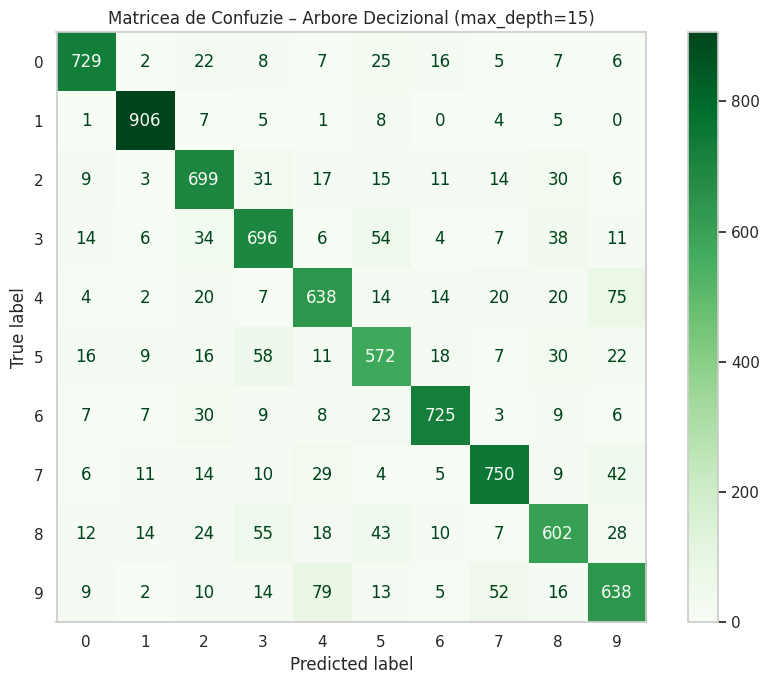

In [ ]:
# Model final arbore
model_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model_dt.fit(X_train_pca, y_train)
y_pred_dt = model_dt.predict(X_test_pca)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"=== Arbore Decizional (max_depth={best_depth}) – Acuratețe: {acc_dt*100:.2f}% ===\n")
print(classification_report(y_test, y_pred_dt))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=list(range(10))
).plot(cmap='Greens', ax=ax, colorbar=True)
plt.title(f'Matricea de Confuzie – Arbore Decizional (max_depth={best_depth})', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

#### 3.4 Comparație algoritmi de clasificare

=== Tabel Comparativ – Clasificare Multiclasă ===


,Model,Acuratețe (%)
0,KNN (K optim),96.86
1,Arbore Decizional (d=15),82.80
2,Nearest Centroid,80.58


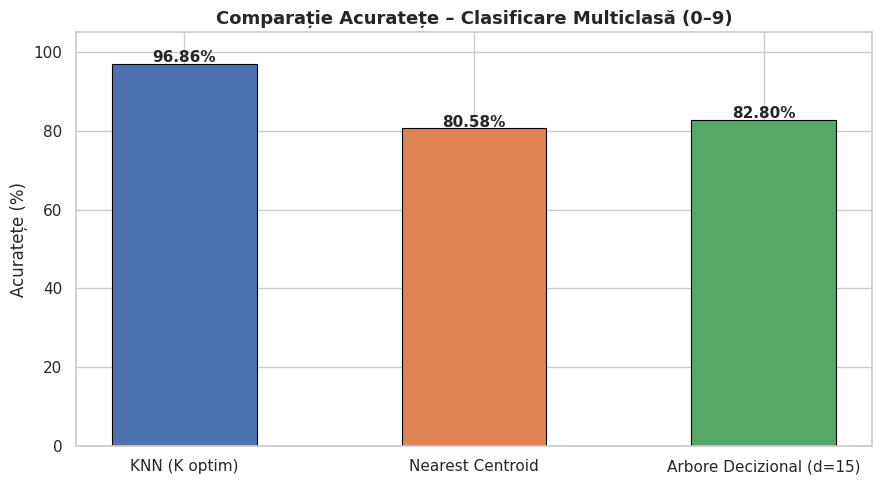

In [ ]:
# Tabel comparativ
results_clf = pd.DataFrame({
    'Model':      ['KNN (K optim)', 'Nearest Centroid', f'Arbore Decizional (d={best_depth})'],
    'Acuratețe (%)': [acc_knn*100, acc_nc*100, acc_dt*100],
})
results_clf['Acuratețe (%)'] = results_clf['Acuratețe (%)'].round(2)
print("=== Tabel Comparativ – Clasificare Multiclasă ===")
display(results_clf.sort_values('Acuratețe (%)', ascending=False).reset_index(drop=True))

# Grafic comparativ
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(9, 5))
bars = plt.bar(results_clf['Model'], results_clf['Acuratețe (%)'],
               color=colors, edgecolor='black', linewidth=0.8, width=0.5)
plt.ylim(0, 105)
for bar, val in zip(bars, results_clf['Acuratețe (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Comparație Acuratețe – Clasificare Multiclasă (0–9)', fontsize=13, fontweight='bold')
plt.ylabel('Acuratețe (%)')
plt.tight_layout()
plt.show()

#### 3.5 Concluzii clasificare multiclasa

1. KNN obține cea mai bună acuratețe dintre cei trei algoritmi, deoarece
  captează granițe de decizie complexe și neregulate

2. Nearest Centroid este cel mai rapid și mai simplu, dar presupune că
  cifrele formează clustere compacte și sferice— ipoteză
  parțial validă pentru unele cifre (ex. `1`), dar slabă pentru altele
  cu forme variate (ex. `8` vs `3`, `4` vs `9`).

3. Arborele Decizional oferă un echilibru bun între interpretabilitate
  și performanță. Alegerea lui `max_depth` este esențială: cu adâncimea optimă, performanța pe test este
  competitivă cu ceilalți algoritmi.

4. Erori frecvente (vizibile în matricile de confuzie): `4` si `9`, `3` si `8`,
  `7` si `1` — cifre care sunt vizual similare.

### 4. Reducere Dimensională – MDS (Multidimensional Scaling)

**MDS** este o tehnică de reducere dimensională care proiectează datele
dintr-un spațiu de dimensiune înaltă ($n$ features) într-un spațiu
de dimensiune redusă (de obicei 2D sau 3D), **păstrând cât mai fidel
distanțele dintre puncte**.


Fie $\delta_{ij}$ distanța originală între punctele $i$ și $j$, și
$d_{ij}$ distanța în spațiul redus. MDS minimizează **stress-ul**:

$$\text{Stress} = \sqrt{\frac{\sum_{i < j}(\delta_{ij} - d_{ij})^2}{\sum_{i < j} \delta_{ij}^2}}$$

MDS este $\mathcal{O}(n^2)$ în memorie și timp.
Lucrăm pe un **eșantion de 600 de imagini** (câte 60 per cifră),
extras stratificat din setul de test.

In [ ]:
# Eșantion stratificat: 60 imagini × 10 cifre = 600 puncte
np.random.seed(42)
idx_mds = []
for digit in range(10):
    idx_digit = np.where(y_test == digit)[0]
    idx_mds.extend(np.random.choice(idx_digit, size=60, replace=False))

X_mds = X_test_pca[idx_mds]
y_mds = y_test[idx_mds]

print(f"Subset MDS: {X_mds.shape[0]} imagini × {X_mds.shape[1]} componente PCA")

# Aplicăm MDS → 2D
print("\nAplicăm MDS (acest pas poate dura câteva zeci de secunde)...")
mds = MDS(n_components=2, random_state=42, normalized_stress=False)
X_mds_2d = mds.fit_transform(X_mds)

# Calculăm stress normalizat manual (formula Kruskal)
from sklearn.metrics import pairwise_distances
D_orig = pairwise_distances(X_mds)
D_2d   = pairwise_distances(X_mds_2d)
stress_norm = np.sqrt(
    np.sum((D_orig - D_2d)**2) / np.sum(D_orig**2)
)

print(f"Stress normalizat (Kruskal): {stress_norm:.4f}")

Subset MDS: 600 imagini × 153 componente PCA

Aplicăm MDS (acest pas poate dura câteva zeci de secunde)...
Stress normalizat (Kruskal): 0.3595
(Stress < 0.05 = excelent | < 0.1 = bun | < 0.2 = acceptabil | > 0.2 = slab)


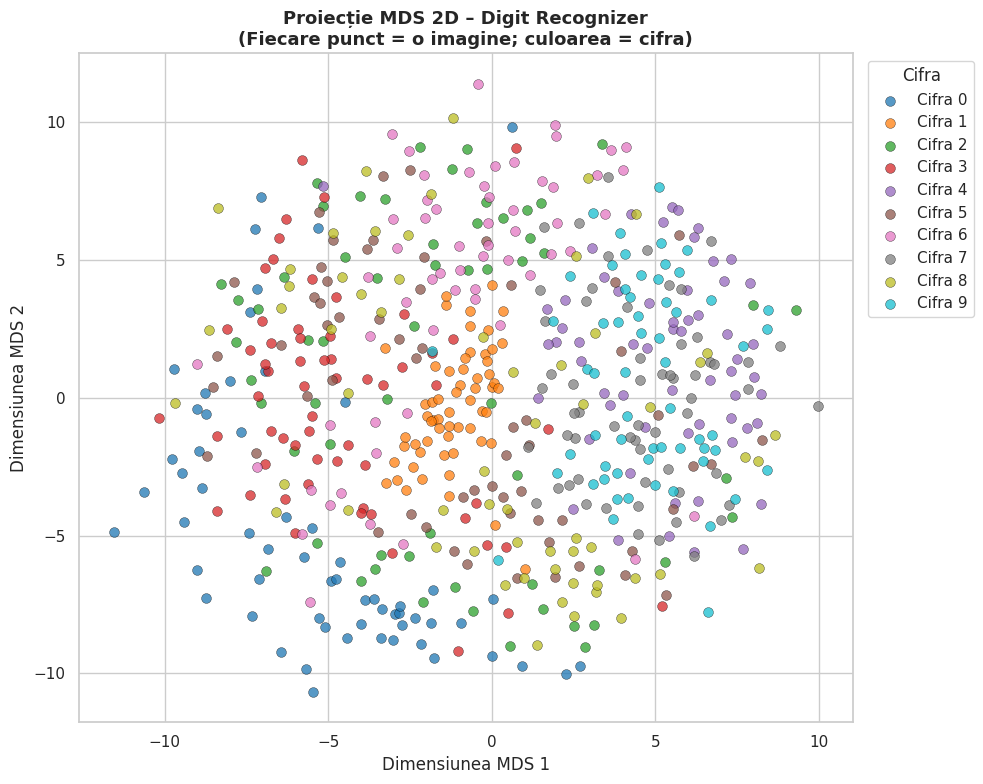

In [ ]:
palette = sns.color_palette("tab10", 10)

plt.figure(figsize=(10, 8))
for digit in range(10):
    mask = y_mds == digit
    plt.scatter(X_mds_2d[mask, 0], X_mds_2d[mask, 1],
                label=f'Cifra {digit}', color=palette[digit],
                alpha=0.75, s=50, edgecolors='black', linewidths=0.3)

plt.title('Proiecție MDS 2D – Digit Recognizer\n'
          '(Fiecare punct = o imagine; culoarea = cifra)', fontsize=13, fontweight='bold')
plt.xlabel('Dimensiunea MDS 1')
plt.ylabel('Dimensiunea MDS 2')
plt.legend(title='Cifra', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 4.1 Interpretarea Proiecției MDS

Proiecția MDS 2D arată o suprapunere semnificativă între clasele de cifre.

Spațiul 2D nu este suficient pentru a separa complet cele 10 clase.
  Informația discriminativă este distribuită pe mai multe dimensiuni.


Totuși, se observă o ușoară tendință de grupare: cifra **1** (portocaliu)
  apare mai concentrată, iar cifrele **0** și **6** prezintă zone de densitate
  mai ridicată în anumite regiuni ale graficului.


Valoarea stress confirmă cantitativ fidelitatea proiecției:
  cu cât este mai aproape de 0, cu atât distanțele 2D reflectă mai fidel
  structura originală.

Suprapunerea observată este așteptată și corectă: compresia de la 153
dimensiuni la 2D implică inevitabil pierdere de informație separatoare.

### 5. Clustering

Algoritmii de clustering grupează datele fără a folosi etichetele, în mod
nesupervizat. Aplicăm clustering cu $k = 10$ clustere (câte unul pentru fiecare cifră)
și comparăm grupările găsite cu etichetele reale.

**Metrici de evaluare:**

| Metrică | Descriere | Interval |
|---|---|---|
| **ARI** (Adjusted Rand Index) | Similitudinea cu etichetele adevărate, corectat pentru hazard | $[-1, 1]$ — 1 = perfect |
| **Silhouette Score** | Cât de bine separat este fiecare punct față de clusterul său și față de cele vecine | $[-1, 1]$ — 1 = optim |

K-Medoids și Clustering Ierarhic necesită mai multă memorie.
Le aplicăm pe 3.000 (K-Medoids), respectiv 1.000 (Ierarhic) de eșantioane.
K-Means rulează pe întregul set de antrenament.

#### 5.1 K-Means

           K-MEANS  (k=10)
  Inertie    : 1,230,540
  ARI        : 0.3655
  Silhouette : 0.0648


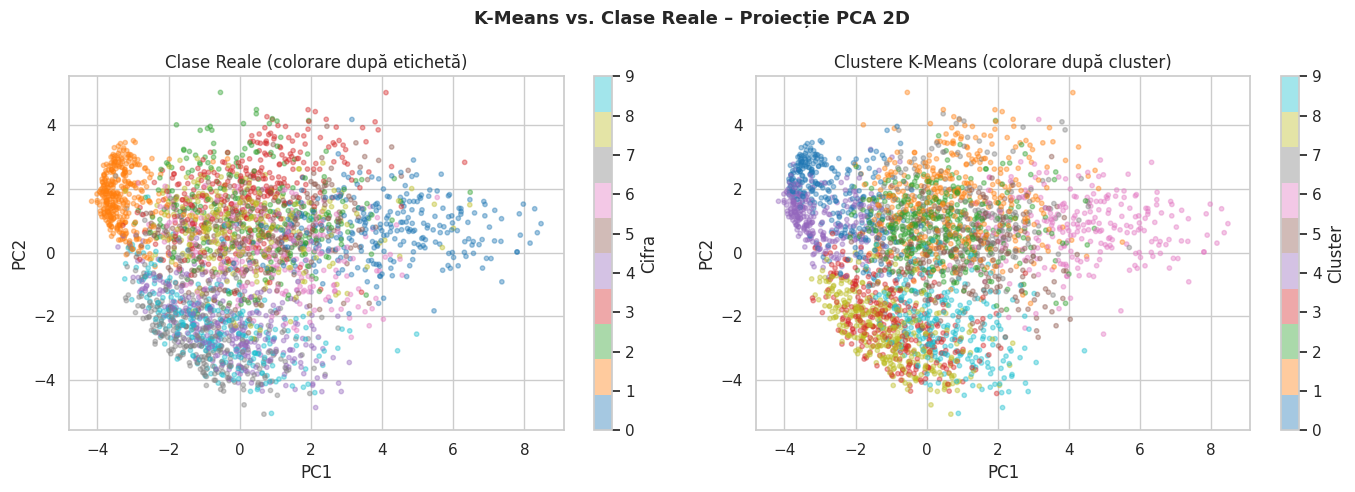

In [ ]:
# ─── K-Means ───────────────────────────────────────────────────────────────
print("=" * 50)
print("           K-MEANS  (k=10)")
print("=" * 50)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train_pca)
labels_km = kmeans.labels_

ari_km  = adjusted_rand_score(y_train, labels_km)
sil_km  = silhouette_score(X_train_pca, labels_km, sample_size=5000, random_state=42)

print(f"  Inertie    : {kmeans.inertia_:,.0f}")
print(f"  ARI        : {ari_km:.4f}")
print(f"  Silhouette : {sil_km:.4f}")

# Vizualizare în 2D PCA
pca2 = PCA(n_components=2, random_state=42)
X_train_2d = pca2.fit_transform(X_train_norm)

# Subset pentru vizualizare
n_viz = 3000
idx_viz = np.random.choice(len(X_train_2d), size=n_viz, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_train_2d[idx_viz, 0], X_train_2d[idx_viz, 1],
                            c=y_train[idx_viz], cmap='tab10', alpha=0.4, s=10)
axes[0].set_title('Clase Reale (colorare după etichetă)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cifra')

scatter2 = axes[1].scatter(X_train_2d[idx_viz, 0], X_train_2d[idx_viz, 1],
                            c=labels_km[idx_viz], cmap='tab10', alpha=0.4, s=10)
axes[1].set_title('Clustere K-Means (colorare după cluster)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('K-Means vs. Clase Reale – Proiecție PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.2 K-Medoids

K-Medoids alege ca reprezentant al fiecărui cluster un punct real din date: medoidul.

$$m_k = \arg\min_{x \in C_k} \sum_{x' \in C_k} d(x, x')$$

Implementăm algoritmul
**PAM** (Partitioning Around Medoids):

1. Inițializăm $k$ medoizi aleatoriu
2. Atribuim fiecare punct medoidului cel mai apropiat
3. Recalculăm medoidul fiecărui cluster (punctul cu distanța totală minimă față de restul)
4. Repetăm până la convergență

        K-MEDOIDS  (k=10, PAM manual)
  Convergență la iterația 4
  Inertie    : 22,064.44
  ARI        : 0.3151
  Silhouette : 0.0723


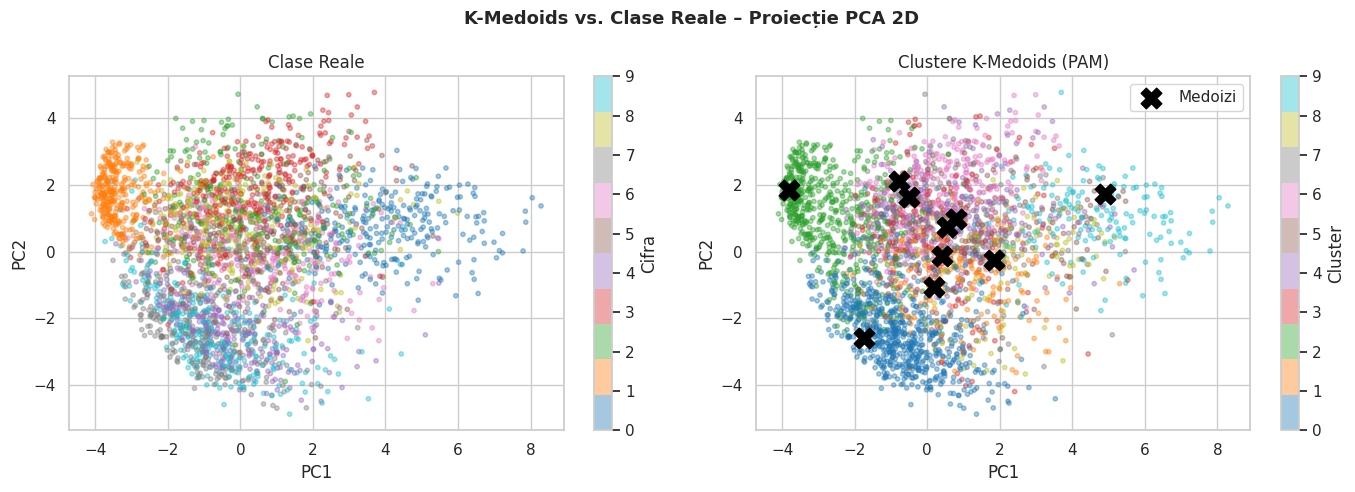

In [ ]:
# ─── K-Medoids ───────────────────────────────────────────────────────────────
from sklearn.metrics import pairwise_distances

def fit_kmedoids(X, k, max_iter=100, random_state=42):
    """
    Algoritmul PAM (Partitioning Around Medoids).
    Returnează: labels, indecșii medoizilor, inertia
    """
    np.random.seed(random_state)
    n = len(X)

    # Precomputăm matricea de distanțe (n × n)
    D = pairwise_distances(X, metric='euclidean')

    # Inițializare aleatorie a medoizilor
    medoid_idx = np.random.choice(n, k, replace=False)

    for iteration in range(max_iter):
        # Pas 1: Atribuim fiecare punct medoidului cel mai apropiat
        labels = np.argmin(D[:, medoid_idx], axis=1)

        new_medoids = medoid_idx.copy()

        # Pas 2: Recalculăm medoidul fiecărui cluster
        for j in range(k):
            cluster_pts = np.where(labels == j)[0]
            if len(cluster_pts) == 0:
                continue
            # Medoidul = punctul cu suma minimă a distanțelor față de ceilalți
            sub_D = D[np.ix_(cluster_pts, cluster_pts)]
            new_medoids[j] = cluster_pts[np.argmin(sub_D.sum(axis=1))]

        # Pas 3: Verificăm convergența
        if np.all(new_medoids == medoid_idx):
            print(f"  Convergență la iterația {iteration + 1}")
            break
        medoid_idx = new_medoids

    # Atribuire finală
    labels = np.argmin(D[:, medoid_idx], axis=1)
    inertia = sum(D[i, medoid_idx[labels[i]]] for i in range(n))
    return labels, medoid_idx, inertia


# ─── Aplicare pe subset 3000 ────────────────────────────────────────────────
print("=" * 50)
print("        K-MEDOIDS  (k=10, PAM manual)")
print("=" * 50)

np.random.seed(42)
idx_med = np.random.choice(len(X_train_pca), size=3000, replace=False)
X_med   = X_train_pca[idx_med]
y_med   = y_train[idx_med]

labels_kmed, medoid_indices, inertia_kmed = fit_kmedoids(X_med, k=10, random_state=42)

ari_kmed = adjusted_rand_score(y_med, labels_kmed)
sil_kmed = silhouette_score(X_med, labels_kmed)

print(f"  Inertie    : {inertia_kmed:,.2f}")
print(f"  ARI        : {ari_kmed:.4f}")
print(f"  Silhouette : {sil_kmed:.4f}")

# ─── Vizualizare ─────────────────────────────────────────────────────────────
X_med_2d = pca2.transform(X_train_norm[idx_med])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_med_2d[:, 0], X_med_2d[:, 1],
                            c=y_med, cmap='tab10', alpha=0.4, s=10)
axes[0].set_title('Clase Reale')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cifra')

scatter2 = axes[1].scatter(X_med_2d[:, 0], X_med_2d[:, 1],
                            c=labels_kmed, cmap='tab10', alpha=0.4, s=10)

# Marcăm medoizii pe grafic
medoid_2d = X_med_2d[medoid_indices]
axes[1].scatter(medoid_2d[:, 0], medoid_2d[:, 1],
                marker='X', s=220, color='black', zorder=5, label='Medoizi')
axes[1].set_title('Clustere K-Medoids (PAM)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('K-Medoids vs. Clase Reale – Proiecție PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.3 Clustering ierarhic

    CLUSTERING IERARHIC  (k=10)


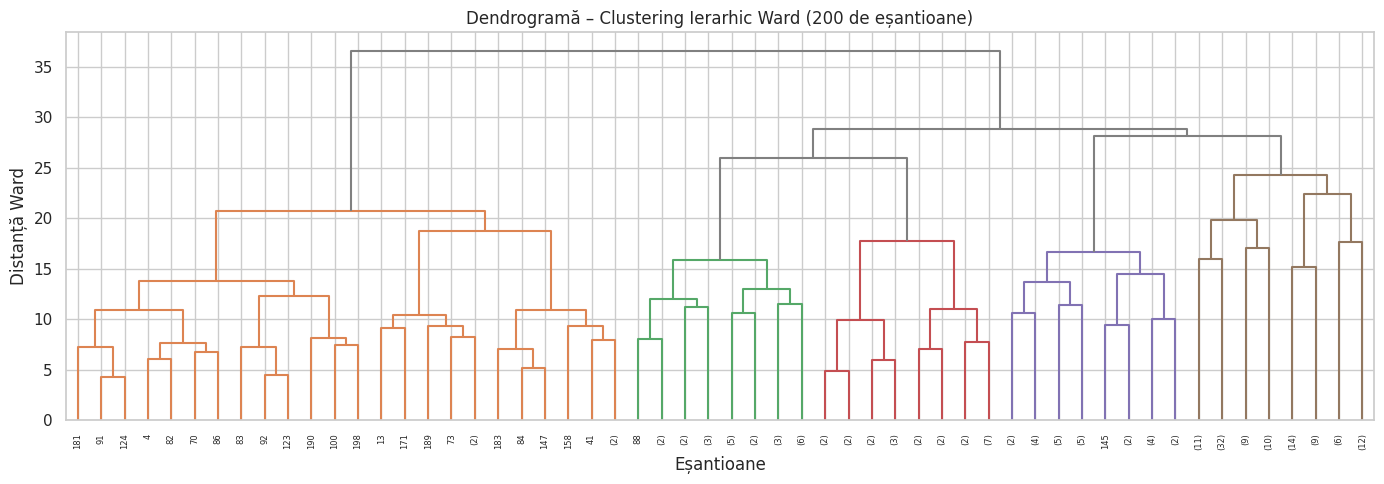

  ARI        : 0.3587
  Silhouette : 0.0396


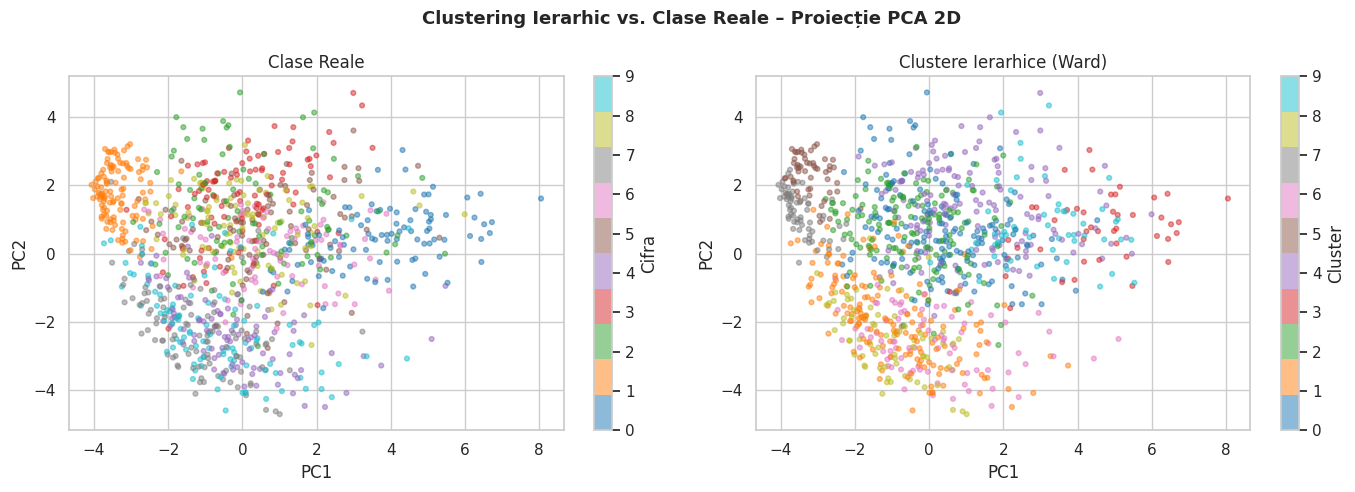

In [ ]:
# ─── Clustering Ierarhic ───────────────────────────────────────────────────
print("=" * 50)
print("    CLUSTERING IERARHIC  (k=10)")
print("=" * 50)

np.random.seed(42)
idx_hier = np.random.choice(len(X_train_pca), size=1000, replace=False)
X_hier   = X_train_pca[idx_hier]
y_hier   = y_train[idx_hier]

# Dendrogramă (pe subset mai mic)
idx_dend  = np.random.choice(len(X_hier), size=200, replace=False)
Z = linkage(X_hier[idx_dend], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=5,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
plt.title('Dendrogramă – Clustering Ierarhic Ward (200 de eșantioane)', fontsize=12)
plt.xlabel('Eșantioane')
plt.ylabel('Distanță Ward')
plt.tight_layout()
plt.show()

# Model cu k=10
hier = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels_hier = hier.fit_predict(X_hier)

ari_hier  = adjusted_rand_score(y_hier, labels_hier)
sil_hier  = silhouette_score(X_hier, labels_hier)

print(f"  ARI        : {ari_hier:.4f}")
print(f"  Silhouette : {sil_hier:.4f}")

X_hier_2d = pca2.transform(X_train_norm[idx_hier])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(X_hier_2d[:, 0], X_hier_2d[:, 1],
                            c=y_hier, cmap='tab10', alpha=0.5, s=12)
axes[0].set_title('Clase Reale')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cifra')

scatter2 = axes[1].scatter(X_hier_2d[:, 0], X_hier_2d[:, 1],
                            c=labels_hier, cmap='tab10', alpha=0.5, s=12)
axes[1].set_title('Clustere Ierarhice (Ward)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Clustering Ierarhic vs. Clase Reale – Proiecție PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.4 Comparație Algoritmi de Clustering

=== Tabel Comparativ – Algoritmi de Clustering (k=10) ===


,Algoritm,Set,ARI,Silhouette
0,K-Means,Antrenament complet,0.3655,0.0648
1,Ierarhic (Ward),Subset 1000,0.3587,0.0396
2,K-Medoids,Subset 3000,0.3151,0.0723


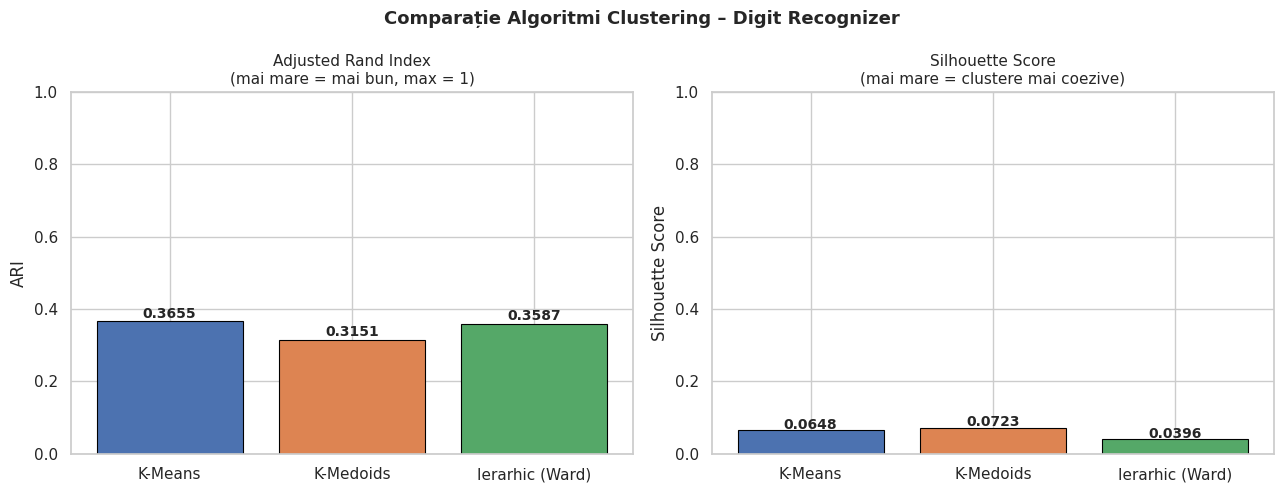

In [ ]:
results_clust = pd.DataFrame({
    'Algoritm'   : ['K-Means', 'K-Medoids', 'Ierarhic (Ward)'],
    'Set'        : ['Antrenament complet', 'Subset 3000', 'Subset 1000'],
    'ARI'        : [round(ari_km, 4), round(ari_kmed, 4), round(ari_hier, 4)],
    'Silhouette' : [round(sil_km, 4), round(sil_kmed, 4), round(sil_hier, 4)],
})

print("=== Tabel Comparativ – Algoritmi de Clustering (k=10) ===")
display(results_clust.sort_values('ARI', ascending=False).reset_index(drop=True))

# Grafic comparativ ARI și Silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_c = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(results_clust['Algoritm'], results_clust['ARI'],
            color=colors_c, edgecolor='black', linewidth=0.8)
axes[0].set_title('Adjusted Rand Index\n(mai mare = mai bun, max = 1)', fontsize=11)
axes[0].set_ylabel('ARI')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_clust['ARI']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(results_clust['Algoritm'], results_clust['Silhouette'],
            color=colors_c, edgecolor='black', linewidth=0.8)
axes[1].set_title('Silhouette Score\n(mai mare = clustere mai coezive)', fontsize=11)
axes[1].set_ylabel('Silhouette Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_clust['Silhouette']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparație Algoritmi Clustering – Digit Recognizer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.5 Concluzii Clustering

1. K-Means este cel mai scalabil algoritm și obține rezultate competitive
  pe întregul set de antrenament.

2. K-Medoids este mai robust la outlieri decât K-Means, deoarece
  fiecare centru de cluster este un punct real din date (medoid), nu o medie.
  Obține rezultate similare cu K-Means, dar cu cost computațional mai mare

3. Clustering Ierarhic construiește o ierarhie completă de clustere
  vizibilă în dendrogramă



#### 6. Concluzii

Setul Digit Recognizer demonstrează clar impactul complexității algoritmului
asupra performanței:
- KNN capturează granițe de decizie locale complexe => acuratețe ridicată
- Nearest Centroid face o simplificare extremă => acuratețe moderată, dar
  interpretabilitate maximă și viteză
- Arborele Decizional oferă echilibrul optim între interpretabilitate și performanță,
  cu condiția reglajului corect al adâncimii

Rolul PCA ca etapă de preprocesare s-a dovedit esențial: reducerea de la
784 la ~150 componente a accelerat toți algoritmii fără pierdere semnificativă
de informație.